# Data Engineering

In [3]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install hdfs

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for hdfs: filename=hdfs-2.7.3-py3-none-any.whl size=34352 sha256=db22692c7aa2b883eb9d85ffa1bad19c32a0dd9a52e84288530e1c8fc5d43966
  Stored in directory: c:\users\ziyan\appdata\local\pip\cache\wheels\97\ae\d9\536505928dd3a458b206013b02625df8f12d22fa154f2bfd65
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13775 sha256=fbbd3116b4746087773f32ad8859b1fd95cd7dc4868511d04dae27405a57b488
  Stored in directory: c:\users\ziyan\appdata\local\pip\cache\wheels\1a\bf\a1\4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built hdfs docopt
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install Sastrawi

In [7]:
pip install langdetect

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install langid

     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------- ----------------------------- 0.5/1.9 MB 2.8 MB/s eta 0:00:01
     --------------------- ------------------ 1.0/1.9 MB 3.3 MB/s eta 0:00:01
     -------------------------------------- - 1.8/1.9 MB 3.2 MB/s eta 0:00:01
     ---------------------------------------- 1.9/1.9 MB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941178 sha256=c56268c77c20372b1d4b85fb6609e99b7e22de1c3abb0c09574a7414c2495d28
  Stored in directory: c:\users\ziyan\appdata\local\pip\cache\wheels\3c\bc\9d\266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid
Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install pymongo beautifulsoup4 requests

   ---------------------------------------- 0.0/910.9 kB ? eta -:--:--
   ----------------------- ---------------- 524.3/910.9 kB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 910.9/910.9 kB 2.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# Task 1: Data Collection and Preparation

## Imports and Intialization

In [12]:
pip install pyspark

     ---------------------------------------- 0.0/434.2 MB ? eta -:--:--
     ---------------------------------------- 0.8/434.2 MB 4.2 MB/s eta 0:01:44
     ---------------------------------------- 2.6/434.2 MB 7.2 MB/s eta 0:01:01
     ---------------------------------------- 5.0/434.2 MB 8.4 MB/s eta 0:00:52
      --------------------------------------- 6.3/434.2 MB 7.9 MB/s eta 0:00:55
      --------------------------------------- 8.1/434.2 MB 7.9 MB/s eta 0:00:55
      -------------------------------------- 10.0/434.2 MB 8.2 MB/s eta 0:00:52
     - ------------------------------------- 11.5/434.2 MB 8.0 MB/s eta 0:00:53
     - ------------------------------------- 13.4/434.2 MB 8.1 MB/s eta 0:00:53
     - ------------------------------------- 14.7/434.2 MB 8.0 MB/s eta 0:00:53
     - ------------------------------------- 15.7/434.2 MB 7.6 MB/s eta 0:00:55
     - ------------------------------------- 16.5/434.2 MB 7.3 MB/s eta 0:00:58
     - ------------------------------------- 17

In [13]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, StringType
from data_collector import URLGenerator, DataCollector, process_article 
from data_cleaner import DataCleaner
from data_processor import DataProcessor
from data_exporter import DataExporter

# Initialize Spark session
spark = SparkSession.builder.appName("Article Processing Pipeline").config("spark.ui.port","4050").getOrCreate()


## 1.1 Data Collection

# Web Scraping

## Save Articles to a File

In [15]:
pip install kafka-python

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from data_collector import URLGenerator, DataCollector, process_article
from kafka_client import KafkaProducerClient, KafkaConsumerClient
import time
from threading import Thread

def process_article_and_send_to_kafka(article_id, url_generator, collector, kafka_producer, file):
    """Generate URL, scrape the article, send to Kafka, and save to a file."""
    article = process_article(article_id, url_generator, collector)
    if article:
        # Send the article to Kafka
        kafka_producer.send_article(article)

        # Write URL, title, and content to the file
        file.write(f"URL: {article['url']}\n")
        file.write(f"Title: {article['title']}\n\n")
        file.write(f"Content:\n{article['content']}\n")
        file.write("-" * 80 + "\n")
        print(f"Saved article: {article['title']} to file and sent to Kafka.")

def main():
    # Initialize classes for URL generation, data collection, and Kafka producer
    url_generator = URLGenerator(base_url="https://www.sinarharian.com.my/article/")
    collector = DataCollector()
    kafka_producer = KafkaProducerClient(kafka_server="localhost:9092", topic="article_topic")

    # Article IDs range
    article_ids = range(701599, 701767 + 1)

    # Open the file in write mode (creates or overwrites the file)
    file_path = "articles_crawled.txt"
    with open(file_path, "w", encoding="utf-8") as f:
        # Process articles, send them to Kafka, and save them to the file
        for article_id in article_ids:
            process_article_and_send_to_kafka(article_id, url_generator, collector, kafka_producer, f)
            time.sleep(1)  # Simulate streaming delay between sending articles

    # Close Kafka producer after sending articles
    kafka_producer.close()

    print(f"All articles have been saved to {file_path} and sent to Kafka.")

if __name__ == "__main__":
    main()

## Upload to HDFS

In [17]:
# Upload the file to HDFS
!hdfs dfs -put -f /home/student/articles_crawled.txt /user/student/articles_crawled.txt
print("File successfully uploaded to HDFS")


File successfully uploaded to HDFS


'hdfs' is not recognized as an internal or external command,
operable program or batch file.


## Read Data

In [ ]:
# Step 2: Read Data
df = spark.read.text("articles_crawled.txt")

# Display the first few rows
df.show(20)

+--------------------+
|               value|
+--------------------+
|URL: https://www....|
|Title: Salah perk...|
|                    |
|            Content:|
|GERGASI Liga Perd...|
|Gol tunggal perla...|
|Kemenangan itu ju...|
|Girona beraksi di...|
|Penjaga gol Liver...|
|Separuh masa kedu...|
|"Enam kemenangan ...|
|"Ia tidak mudah u...|
|                    |
|"Sejujurnya, kami...|
|Sementara itu, pe...|
|                    |
|"Sudah tiba masan...|
|    LIGA JUARA-JUARA|
|           Keputusan|
|FC Dynamo Zagreb ...|
+--------------------+
only showing top 20 rows



## 1.2 Clean Data

In [ ]:
# Initialize and use DataCleaner
cleaner = DataCleaner()

# Step 1: Clean Data
cleaned_df = cleaner.clean_data(df)

# Step 2: Format Data
 # Convert DataFrame to RDD and process it
formatted_df = cleaner.format_data(cleaned_df)
print("Formatted DataFrame:")
data_preview = formatted_df.take(10)  # Retrieve first 10 records
for row in data_preview:
    print(row["combined_text"])


Formatted DataFrame:
salah perkukuh cengkaman liverpool di tangga teratas liga juara-juara gergasi liga perdana inggeris liverpool mengekalkan rekod peratus tanpa kalah dalam liga juara-juara musim ini apabila meraih kemenangan ke atas kelab la liga sepanyol girona di stadium montilivi girona gol tunggal perlawanan dijelmakan menerusi penalti penyerang sensasi the reds mohamed salah pada minit ke memastikan liverpool mengumpul mata selepas mengharungi enam perlawanan kemenangan itu juga mengekalkan liverpool kendalian arne slot di tangga teratas liga lima mata di depan bayer leverkusen dan aston villa manakala girona pula kekal dengan tiga mata di tangga ke girona beraksi di laman sendiri tampil agresif sepanjang minit pertama bagi menghindari kekalahan kelima dalam pertandingan itu namun liverpool berjaya menyerap tekanan berusaha menyaingi blanquivermells kendalian michel penjaga gol liverpool alisson membuat penampilan pertamanya sejak awal oktober selepas kecederaan hamstring tampi

## 1.3 Process Data

In [ ]:
# Instantiate the DataProcessor class
processor = DataProcessor()

# Process the data using the instance
final_df, tokenized_df, df_without_stopwords, minus_df = processor.process_data(formatted_df)

# Display the results
data_preview = final_df.select("tokens_excluded").take(10)
for row in data_preview:
    print(row["tokens_excluded"])


[nltk_data] Downloading package words to /home/student/nltk_data...
[nltk_data]   Package words is already up-to-date!
[Stage 3:>                                                          (0 + 1) / 1]

['salah', 'perkukuh', 'cengkaman', 'liverpool', 'tangga', 'teratas', 'liga', 'juara-juara', 'gergasi', 'perdana', 'inggeris', 'mengekalkan', 'rekod', 'peratus', 'kalah', 'musim', 'apabila', 'meraih', 'kemenangan', 'atas', 'kelab', 'sepanyol', 'girona', 'montilivi', 'tunggal', 'perlawanan', 'dijelmakan', 'menerusi', 'penalti', 'penyerang', 'sensasi', 'reds', 'mohamed', 'minit', 'memastikan', 'mengumpul', 'mata', 'selepas', 'mengharungi', 'kendalian', 'arne', 'lima', 'depan', 'bayer', 'leverkusen', 'aston', 'manakala', 'kekal', 'tiga', 'beraksi', 'laman', 'sendiri', 'tampil', 'agresif', 'sepanjang', 'pertama', 'menghindari', 'kekalahan', 'kelima', 'pertandingan', 'berjaya', 'menyerap', 'tekanan', 'berusaha', 'menyaingi', 'blanquivermells', 'michel', 'penjaga', 'alisson', 'membuat', 'penampilan', 'pertamanya', 'sejak', 'awal', 'oktober', 'kecederaan', 'cemerlang', 'mengemudi', 'benteng', 'terakhir', 'menafikan', 'beberapa', 'percubaan', 'jentera', 'mendahului', 'permainan', 'separuh', 'ke

## 1.4 Export Tokens

In [ ]:
# Assuming spark is already initialized and final_df is available
exporter = DataExporter(spark)

# Step 1: Flatten tokens from the final DataFrame
flattened_tokens = exporter.flatten_tokens(final_df)

# Step 2: Create a DataFrame from the flattened tokens
tokens_df = exporter.create_tokens_df(flattened_tokens)

# Step 3: Define the output path
output_path = "all_tokens.txt"

# Step 4: Delete the output path if it exists
exporter.delete_if_exists(output_path)

# Step 5: Export the tokens to a text file
exporter.export_tokens(tokens_df, output_path)

[Stage 5:>                                                          (0 + 1) / 1]

Tokens exported to all_tokens.txt


## 1.5 Data Quality

In [ ]:
from pyspark.sql import functions as F
#1. Check Word Count
# Count the total number of words in 'tokens'
total_token_count = tokenized_df.agg(F.sum(F.size(F.col("tokens"))).alias("total_token_count")).collect()[0]["total_token_count"]
# Count the total number of words in 'deduplicated_tokens'
total_deduplicated_token_count = tokenized_df.agg(F.sum(F.size(F.col("deduplicated_tokens"))).alias("total_deduplicated_token_count")).collect()[0]["total_deduplicated_token_count"]
# Count the total number of words in 'filtered_tokens'
total_filtered_token_count = df_without_stopwords.agg(F.sum(F.size(F.col("filtered_tokens"))).alias("total_filtered_token_count")).collect()[0]["total_filtered_token_count"]
# Count the total number of words in 'tokens_excluded'
total_tokens_excluded_count = final_df.agg(F.sum(F.size(F.col("tokens_excluded"))).alias("total_tokens_excluded_count")).collect()[0]["total_tokens_excluded_count"]

# Print the totals
excluded_english_words = total_deduplicated_token_count - total_tokens_excluded_count-total_filtered_token_count
print(f"---Word Count Record---")
print(f"Original Tokens     : {total_token_count}")
print(f"Deduplicated Tokens : {total_deduplicated_token_count}")
print(f"Stop Words Tokens   : {total_filtered_token_count}")
print(f"English Words Tokens: {excluded_english_words}")
print(f"Final Tokens        : {total_tokens_excluded_count}")
print(f"")

---Word Count Record---
Original Tokens     : 4630
Deduplicated Tokens : 1381
Stop Words Tokens   : 68
English Words Tokens: 122
Final Tokens        : 1191



In [ ]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install redis

Note: you may need to restart the kernel to use updated packages.


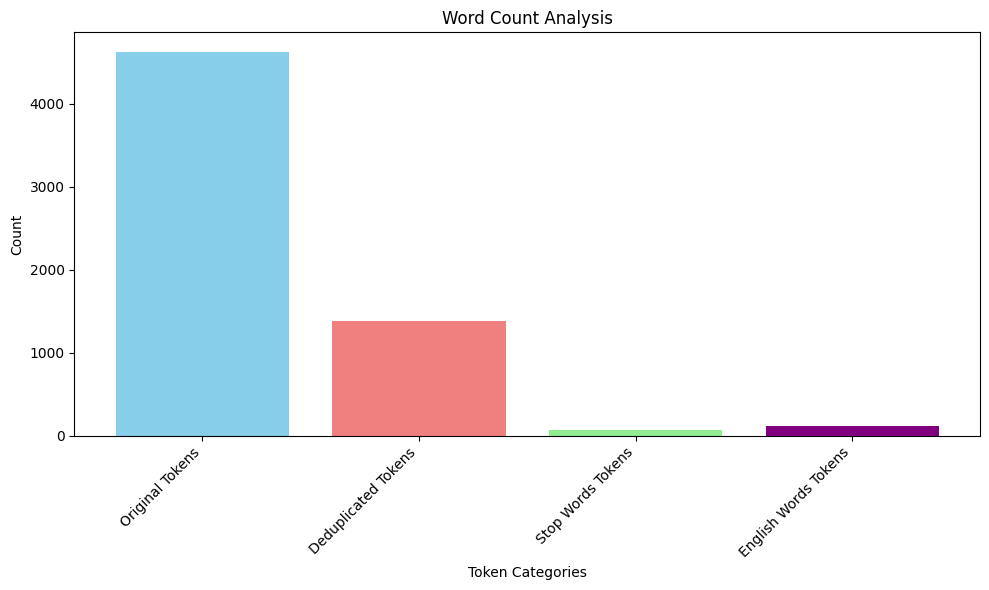

In [ ]:
import redis
import matplotlib.pyplot as plt
import pandas as pd

# Connect to Redis
redis_client = redis.StrictRedis(host='localhost', port=6379, decode_responses=True)

# Example token count data
data = {
    'original_tokens': total_token_count,
    'deduplicated_tokens': total_deduplicated_token_count,
    'stop_words_tokens': total_filtered_token_count,
    'english_words_tokens': excluded_english_words
}

# Store the data in Redis
for key, value in data.items():
    redis_client.set(key, value)

# Retrieve the data from Redis
retrieved_data = {key: int(redis_client.get(key)) for key in data.keys()}

# Prepare data for plotting
word_count_data = {
    'Category': ['Original Tokens', 'Deduplicated Tokens', 'Stop Words Tokens', 'English Words Tokens'],
    'Count': [retrieved_data['original_tokens'], 
              retrieved_data['deduplicated_tokens'], 
              retrieved_data['stop_words_tokens'], 
              retrieved_data['english_words_tokens']]
}

# Convert the data to a Pandas DataFrame
word_count_df = pd.DataFrame(word_count_data)

# Define a list of colors for each bar
bar_colors = ['skyblue', 'lightcoral', 'lightgreen', 'purple']

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(word_count_df['Category'], word_count_df['Count'], color=bar_colors)
plt.xlabel('Token Categories')
plt.ylabel('Count')
plt.title('Word Count Analysis')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()

## Missing Tokens

In [ ]:
import redis
from pyspark.sql.functions import when, size, col, array, lit

# Connect to Redis
redis_client = redis.StrictRedis(host='localhost', port=6379, decode_responses=True)

# Check for rows with missing or empty tokens
missing_tokens_count = tokenized_df.filter(size(col("tokens")) == 0).count()

# Store the count in Redis
redis_client.set("missing_tokens_count", missing_tokens_count)

# Retrieve the count from Redis
retrieved_count = int(redis_client.get("missing_tokens_count"))

if retrieved_count > 0:
    print(f"There are {retrieved_count} rows with missing tokens in the original 'tokens' column.")

    # Handle rows with missing tokens by filling them with a placeholder or removing them
    # Option 1: Fill missing tokens with a placeholder (e.g., ['missing'])
    tokenized_df = tokenized_df.withColumn(
        "tokens",
        when(size(col("tokens")) == 0, array(lit("missing"))).otherwise(col("tokens"))
    )
    print("Missing tokens have been handled by filling them with a placeholder: ['missing'].")

else:
    print("No missing tokens found in the original 'tokens' column.")


No missing tokens found in the original 'tokens' column.


# Duplicates Token

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, StringType, IntegerType
import pandas as pd

# Function to get duplicate tokens and their counts
def get_duplicate_counts(tokens):
    token_counts = {}
    duplicates = []
    
    # Count occurrences of each token
    for token in tokens:
        token_counts[token] = token_counts.get(token, 0) + 1
    
    # Add to duplicates those that appear more than once
    for token, count in token_counts.items():
        if count > 1:
            duplicates.append((token, count))
    
    return duplicates

# UDF to apply the duplication check and get the counts
get_duplicate_counts_udf = udf(get_duplicate_counts, ArrayType(ArrayType(StringType())))

# Step 1: Check duplicates in original tokens (before deduplication or stop word removal)
original_duplicates_df = tokenized_df.withColumn("original_duplicates", get_duplicate_counts_udf("tokens"))

# Step 2: Check duplicates in final tokens (after stop word removal and exclusions)
final_duplicates_df = final_df.withColumn("final_duplicates", get_duplicate_counts_udf("tokens_excluded"))

# Collect the results for original duplicates and final duplicates
original_duplicates = original_duplicates_df.collect()[0]["original_duplicates"]
final_duplicates = final_duplicates_df.collect()[0]["final_duplicates"]

# Step 3: Create a DataFrame for original duplicates
print("Duplicate Token Record")
print("---Original Data----")
if original_duplicates:
    original_duplicates_df = spark.createDataFrame(original_duplicates, ["Token", "Count"])
    original_duplicates_df.show()
else:
    print("No duplicates found in the original tokens.")

# Step 4: Create a DataFrame for final duplicates
print("---Final Data---")
if final_duplicates:
    final_duplicates_df = spark.createDataFrame(final_duplicates, ["Token", "Count"])
    final_duplicates_df.show()
else:
    print("No duplicates found in the final tokens.")

Duplicate Token Record
---Original Data----
+-----------+-----+
|      Token|Count|
+-----------+-----+
|      salah|    6|
|  liverpool|   16|
|         di|   93|
|     tangga|    3|
|    teratas|    4|
|       liga|    9|
|juara-juara|    5|
|    gergasi|    2|
|    perdana|    5|
|   inggeris|    2|
|mengekalkan|    4|
|      rekod|    7|
|      tanpa|    4|
|      kalah|    4|
|      dalam|   60|
|      musim|    9|
|        ini|   34|
|    apabila|   25|
|     meraih|    8|
| kemenangan|   35|
+-----------+-----+
only showing top 20 rows

---Final Data---
No duplicates found in the final tokens.


# Duplicate with stop words

In [ ]:
from pyspark.sql import functions as F
import redis

# Connect to Redis
redis_client = redis.StrictRedis(host='localhost', port=6379, decode_responses=True)

# Explode the tokens into individual rows for analysis
exploded_df = tokenized_df.select(F.explode(F.col("tokens")).alias("token"))

# Count the frequency of each token
token_frequency_df = exploded_df.groupBy("token").count().orderBy(F.col("count").desc())

# Store token frequencies in Redis
token_frequency_data = token_frequency_df.collect()
for row in token_frequency_data:
    redis_client.hset("token_frequencies", row["token"], row["count"])

print("Duplicate Token Records With Stop Words")
print("---Original Data (After Word Tokenization)----")

# Retrieve and display the top 10 tokens from Redis
redis_token_data = redis_client.hgetall("token_frequencies")
top_tokens = sorted(redis_token_data.items(), key=lambda x: int(x[1]), reverse=True)[:10]

# Display the DataFrame using df.show()
token_frequency_df.show(10)

Duplicate Token Records With Stop Words
---Original Data (After Word Tokenization)----
+--------+-----+
|   token|count|
+--------+-----+
|      di|   93|
|    yang|   79|
|     dan|   78|
|    pada|   77|
|     itu|   70|
|   dalam|   60|
|  dengan|   52|
|malaysia|   52|
|   untuk|   47|
|   sukan|   43|
+--------+-----+
only showing top 10 rows



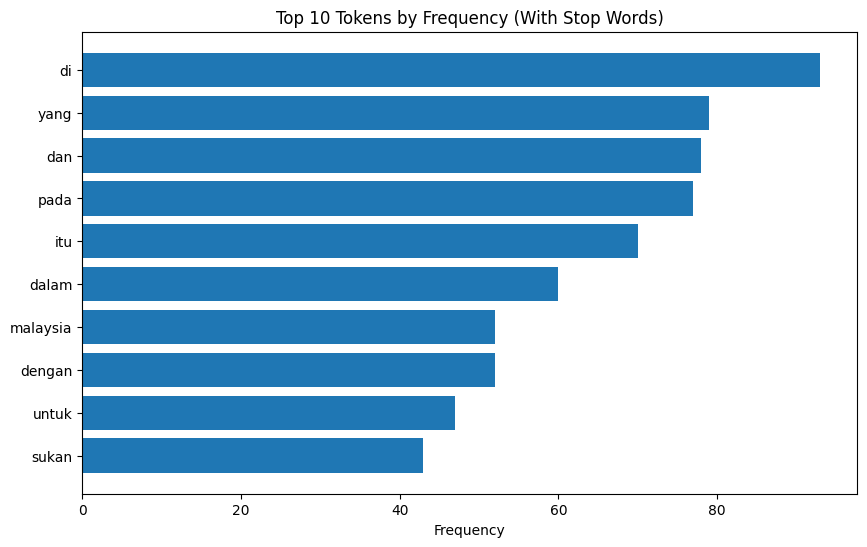

In [ ]:
import matplotlib.pyplot as plt
import redis

# Connect to Redis
redis_client = redis.StrictRedis(host='localhost', port=6379, decode_responses=True)

# Retrieve token frequencies from Redis
redis_token_data = redis_client.hgetall("token_frequencies")

# Sort tokens by frequency in descending order and get the top 10
top_tokens = sorted(redis_token_data.items(), key=lambda x: int(x[1]), reverse=True)[:10]

# Prepare data for plotting
tokens, frequencies = zip(*top_tokens)
frequencies = [int(freq) for freq in frequencies]  # Convert frequencies to integers

# Create a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(tokens, frequencies)
plt.xlabel('Frequency')
plt.title('Top 10 Tokens by Frequency (With Stop Words)')
plt.gca().invert_yaxis()  # Highest frequency on top
plt.show()

Token frequencies stored in Redis.


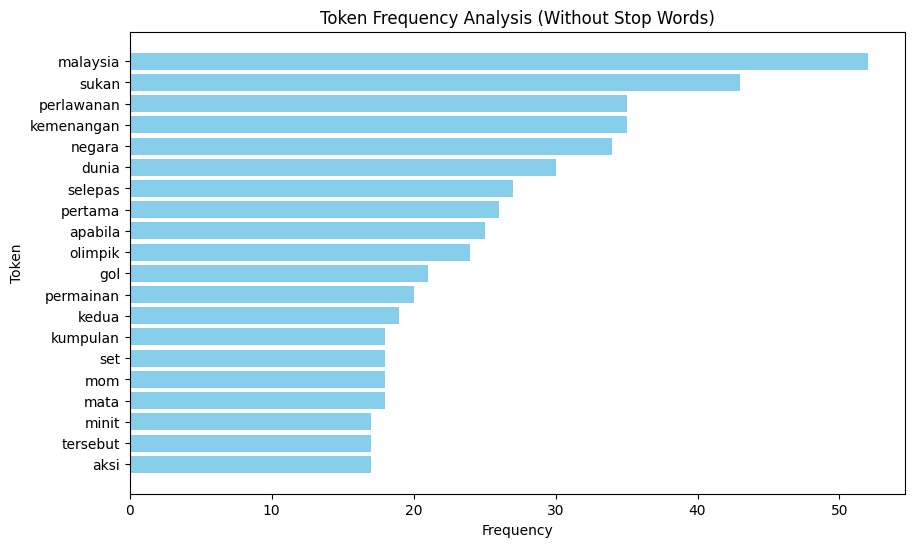

In [ ]:
import matplotlib.pyplot as plt
import redis
import pandas as pd
from pyspark.sql.functions import explode, col

# Connect to Redis
redis_client = redis.StrictRedis(host='localhost', port=6379, decode_responses=True)

# Step 1: Explode the 'minus_tokens' column to get individual tokens
exploded_df = minus_df.withColumn("token", explode(col("minus_tokens")))

# Step 2: Count the frequency of each token
token_counts = exploded_df.groupBy("token").count().orderBy("count", ascending=False)

# Step 3: Store token frequencies in Redis
token_counts_data = token_counts.collect()
for row in token_counts_data:
    redis_client.hset("minus_token_frequencies", row["token"], row["count"])

print("Token frequencies stored in Redis.")

# Step 4: Retrieve token frequencies from Redis
redis_token_data = redis_client.hgetall("minus_token_frequencies")
sorted_tokens = sorted(redis_token_data.items(), key=lambda x: int(x[1]), reverse=True)[:20]  # Top 20 tokens

# Step 5: Prepare data for plotting
tokens, frequencies = zip(*sorted_tokens)
frequencies = [int(freq) for freq in frequencies]  # Convert frequencies to integers
top_tokens_df = pd.DataFrame({"token": tokens, "count": frequencies})

# Step 6: Plotting the Bar Chart using Matplotlib
plt.figure(figsize=(10, 6))
plt.barh(top_tokens_df['token'], top_tokens_df['count'], color='skyblue')

# Add labels and title
plt.xlabel('Frequency')
plt.ylabel('Token')
plt.title('Token Frequency Analysis (Without Stop Words)')

# Show the plot
plt.gca().invert_yaxis()  # Invert y-axis to show the highest frequency at the top
plt.show()

In [ ]:
# Stop the Spark session
spark.stop()
print("Spark session stopped")

Spark session stopped


# Task 2: Lexicon Creation

## Import into MongoDB

In [ ]:
from lexicon_creation import HDFSToMongoDB

# Define variables
hdfs_path = ""
#mongo_uri = ""
mongo_uri = ""
db_name = ""
collection_name = ""
object_id = ""

# Step 1: Initialize the class
hdfs_mongo = HDFSToMongoDB(hdfs_path, mongo_uri, db_name, collection_name, object_id)

# Step 2: Start Spark session
hdfs_mongo.initialize_spark()

# Step 3: Read tokens from HDFS into RDD
tokens_array = hdfs_mongo.read_txt_file()

# Step 4: Update MongoDB (overwrite mode)
result_message = hdfs_mongo.update_mongodb(tokens_array)
print(result_message)

# Step 5: Stop Spark session
hdfs_mongo.stop_spark()

24/12/23 14:38:35 WARN Utils: Service 'SparkUI' could not bind on port 4050. Attempting port 4051.


Tokens overwritten in the existing document in MongoDB!


## Annotation

In [ ]:
from anotation import AnnotationProcess

# MongoDB URI, database, collection name, and ObjectId of the target document
mongo_uri = ""
db_name = ""
collection_name = ""
target_object_id = ""

# Create an AnnotationProcess instance and run the process
process = AnnotationProcess(mongo_uri, db_name, collection_name, target_object_id)
process.run()

2024-12-23 14:38:37.437966: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-23 14:38:37.515246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734935917.553105 2458205 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734935917.565826 2458205 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-23 14:38:37.645708: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Annotation completed including sentiment, POS tagging, and word sense disambiguation. Data updated in MongoDB.


# Task 3: Lexicon Enrichment

## 3.1 Semantic Relations

### 3.1.1 Stemmed Word, Definition, POS, Synonyms, Antonyms, Derived Word

In [ ]:
from pyspark.sql import SparkSession
from lexicon_scraper1 import get_words_from_mongo_by_id, scrape_DBP_data, write_to_csv, Lexicon

# Initialize Spark session
spark = SparkSession.builder \
    .appName("Lexicon Scraper") \
    .getOrCreate()

# ObjectId to fetch the document
object_id = ""

# Get words from MongoDB by ObjectId
words = get_words_from_mongo_by_id(object_id)

if not words:
    print("No words found for the given ObjectId.")
else:
    # Parallelize the list of words using PySpark
    rdd = spark.sparkContext.parallelize(words)

    # Process each word in parallel
    def process_word(word):
        lexicon_entry = scrape_DBP_data(word)
        if lexicon_entry:
            return {
                "word": lexicon_entry.word,
                "stemmed_word": ''.join(lexicon_entry.stemmed_word or []),
                "definitions": '; '.join(lexicon_entry.definitions or []),
                "part_of_speech": lexicon_entry.part_of_speech,
                "contexts": '; '.join(lexicon_entry.contexts or []),
                "synonyms": '; '.join(lexicon_entry.synonyms or []),
                "antonyms": '; '.join(lexicon_entry.antonyms or []),
                "derived_words": ', '.join(lexicon_entry.derived_words or [])
            }
        return None

    # Map the process_word function to each word
    lexicon_rdd = rdd.map(process_word).filter(lambda x: x is not None)

    # Collect the processed data
    lexicon_data = lexicon_rdd.collect()

    if not lexicon_data:
        print("No lexicon data was scraped.")
    else:
        # Save to CSV
        output_filename = "lexicon_data.csv"
        write_to_csv(output_filename, [
            Lexicon(
                word=data["word"],
                stemmed_word=data["stemmed_word"],
                definitions=data["definitions"].split("; "),
                part_of_speech=data["part_of_speech"],
                contexts=data["contexts"].split("; "),
                synonyms=data["synonyms"].split("; "),
                antonyms=data["antonyms"].split("; "),
                derived_words=data["derived_words"].split(", ")
            ) for data in lexicon_data
        ])
        print(f"Data successfully written to {output_filename}")

# Stop Spark session
spark.stop()


24/12/23 14:39:32 WARN Utils: Service 'SparkUI' could not bind on port 4050. Attempting port 4051.
[Stage 0:>                                                        (0 + 18) / 18]INFO:root:Scraping data for merakam...
INFO:root:Scraping data for umbi...
INFO:root:Scraping data for menyumbang...
INFO:root:Scraping data for ferdinansyah-gloria...
INFO:root:Scraping data for lumpur...
INFO:root:Scraping data for jhe-huei-yang...
INFO:root:Scraping data for memakai...
INFO:root:Scraping data for michel...
INFO:root:Scraping data for menerima...
INFO:root:Scraping data for ekuestrian...
INFO:root:Scraping data for kenang...
INFO:root:Scraping data for isu...
INFO:root:Scraping data for kekemasan...
INFO:root:Scraping data for salah...
INFO:root:Scraping data for kesampaian...
INFO:root:Scraping data for bekerja...
INFO:root:Scraping data for emanuelle...
INFO:root:Scraping data for bintang...
INFO:root:Scraping data for penjaga...
INFO:root:Scraping data for pusingan...
INFO:root:Scraping d

Data successfully written to lexicon_data.csv


### 3.1.2 Hypernyms, Hyponyms, Meronyms and Holonyms

In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')  # For multilingual WordNet (includes 'zsm' for Malay)

[nltk_data] Downloading package wordnet to /home/student/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/student/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType, StructType, StructField

from nltk.corpus import wordnet
from lexicon_scraper2 import get_hypernyms_hyponyms_meronyms_holonyms_in_malay

# Read the dataset
data = pd.read_csv("lexicon_data.csv")
data['Hypernyms'] = ''
data['Hyponyms'] = ''
data['Meronyms'] = ''
data['Holonyms'] = ''

# Process each word in the dataset
for index, row in data.iterrows():
    word = row['Word']  # Adjust column name if necessary
    hypernyms, hyponyms, meronyms, holonyms = get_hypernyms_hyponyms_meronyms_holonyms_in_malay(word)
    data.loc[index, 'Hypernyms'] = hypernyms
    data.loc[index, 'Hyponyms'] = hyponyms
    data.loc[index, 'Meronyms'] = meronyms
    data.loc[index, 'Holonyms'] = holonyms

# Export the updated dataset to the same CSV file (overwrite)
data.to_csv("lexicon_data.csv", index=False, encoding='utf-8')

import pandas as pd
df = pd.read_csv('lexicon_data.csv')
df.head(5)



,Word,Stemmed Word,Definitions,Part of Speech,Contexts,Synonyms,Antonyms,Derived Words,Hypernyms,Hyponyms,Meronyms,Holonyms
0,salah,NaN,"[sa.lah] | ساله Definisi : 1. tidak benar, ti...",NaN,NaN,NaN,NaN,NaN,"khilaf, memperhitungkan, mencongak","terjerembat, silap, terlanjur",NaN,NaN
1,cengkaman,NaN,[ceng.ka.man] | چڠکمن Definisi : 1. pegangan ...,NaN,NaN,NaN,NaN,NaN,"kemanjuran, wibawa, gesekan",NaN,NaN,NaN
2,tangga,tangga,[tang.ga] | تڠݢ Definisi : tangga 1. tempat t...,kata nama,NaN,"sigai, peringkat",NaN,bertangga,"darjah, kedudukan, taraf","larian, eskalator, tangga",anak_tangga,"muka_pintu, pintu, jalan_masuk"
3,teratas,NaN,[te.ra.tas]/[ter.a.tas] | تراتس Definisi : te...,NaN,NaN,NaN,NaN,NaN,"sebelah, muka, paras","kemuncak, puncak, kepala",NaN,NaN
4,liga,NaN,[li.ga] | ليݢا Definisi : 1. persatuan atau p...,NaN,NaN,NaN,NaN,NaN,"mempersatukan, memadu, perikatan","pembahagian, kelas, golongan",NaN,NaN


In [24]:
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType, StructType, StructField

from nltk.corpus import wordnet
from lexicon_scraper2 import get_hypernyms_hyponyms_meronyms_holonyms_in_malay

# Read the dataset
data = pd.read_csv("lexicon_data.csv")
data['Hypernyms'] = ''
data['Hyponyms'] = ''
data['Meronyms'] = ''
data['Holonyms'] = ''

# Process each word in the dataset
for index, row in data.iterrows():
    word = row['Word']  # Adjust column name if necessary
    hypernyms, hyponyms, meronyms, holonyms = get_hypernyms_hyponyms_meronyms_holonyms_in_malay(word)
    data.loc[index, 'Hypernyms'] = hypernyms
    data.loc[index, 'Hyponyms'] = hyponyms
    data.loc[index, 'Meronyms'] = meronyms
    data.loc[index, 'Holonyms'] = holonyms

# Export the updated dataset to the same CSV file (overwrite)
data.to_csv("lexicon_data.csv", index=False, encoding='utf-8')

import pandas as pd
df = pd.read_csv('lexicon_data.csv')
df.head(5)



,Word,Stemmed Word,Definitions,Part of Speech,Contexts,Synonyms,Antonyms,Derived Words,Hypernyms,Hyponyms,Meronyms,Holonyms,Sentiment_Score,Sentimental_Label
0,bersiap,siap,[ber.siap] | برسياڤ Definisi : Id jaga sedia!...,kata kerja,NaN,selesai,NaN,"bersiap, bersiap-siap, menyiapkan, persiapan, ...","berkisar, meminda, mendidik","memberi, menggurdi, mengukuhkan",NaN,NaN,0.000000,Neutral
1,india,NaN,Definisi : bangsa yg nenek moyang mereka beras...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Thar_Desert, Sungai_Ganges, Manipur","Asia, Negara-Negara_Komanwel, OPEC",0.116055,Positive
2,tekad,tekad,[té.kad] | تيکد Definisi : (tékad) kemahuan y...,kata nama,NaN,kebulatan hati,NaN,bertekad,"tekad, ciri, penentuan","tekad, kedegilan, kekukuhan",NaN,NaN,0.000000,Neutral
3,memperbaiki,NaN,[mem.per.bai.ki]/[mem.per.bai/.ki] | ممڤرباءي...,NaN,NaN,NaN,NaN,NaN,"menjerumat, mempergilirkan, merajuki","meringankan, membantu, menjerumat",NaN,NaN,0.000000,Neutral
4,kelemahan,lemah,[ke.le.ma.han] | کلمهن Definisi : perihal lem...,kata sifat,NaN,"lesu, lembam","cergas, cerdas","melemahkan, kelemahan","kesialan, ciri, kejahatan","tiada, kecelaan, restu",NaN,NaN,0.383738,Positive


## 3.2 Sentiment Analysis

### 3.2.1 Sentiment Labelling

In [ ]:
from sentiment_labelling import SentimentLabelling
import pandas as pd

In [ ]:
# Instantiate the SentimentLabelling class
sentiment_analyzer = SentimentLabelling()

# Load your dataset
data = pd.read_csv("lexicon_data.csv", encoding='utf-8')

# Apply sentiment analysis and add the score column
data['Sentiment_Score'] = data['Word'].apply(sentiment_analyzer.analyze_sentiment)

# Save the results
data.to_csv("lexicon_data.csv", index=False, encoding='utf-8')

print("Sentiment scores added successfully!")

# Load the updated CSV and display the first 5 rows
df = pd.read_csv('lexicon_data.csv')
df.head(5)# Initialize Spark session


/home/student/de-prj/de-venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/student/de-prj/de-venv/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/student/de-prj/de-venv/lib/python3.10/site-packages/transformers/modeling_utils.py:519: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more 

Sentiment scores added successfully!


,Word,Stemmed Word,Definitions,Part of Speech,Contexts,Synonyms,Antonyms,Derived Words,Hypernyms,Hyponyms,Meronyms,Holonyms,Sentiment_Score
0,salah,NaN,"[sa.lah] | ساله Definisi : 1. tidak benar, ti...",NaN,NaN,NaN,NaN,NaN,"khilaf, memperhitungkan, mencongak","terjerembat, silap, terlanjur",NaN,NaN,-0.483500
1,cengkaman,NaN,[ceng.ka.man] | چڠکمن Definisi : 1. pegangan ...,NaN,NaN,NaN,NaN,NaN,"kemanjuran, wibawa, gesekan",NaN,NaN,NaN,0.000000
2,tangga,tangga,[tang.ga] | تڠݢ Definisi : tangga 1. tempat t...,kata nama,NaN,"sigai, peringkat",NaN,bertangga,"darjah, kedudukan, taraf","larian, eskalator, tangga",anak_tangga,"muka_pintu, pintu, jalan_masuk",0.000000
3,teratas,NaN,[te.ra.tas]/[ter.a.tas] | تراتس Definisi : te...,NaN,NaN,NaN,NaN,NaN,"sebelah, muka, paras","kemuncak, puncak, kepala",NaN,NaN,0.000000
4,liga,NaN,[li.ga] | ليݢا Definisi : 1. persatuan atau p...,NaN,NaN,NaN,NaN,NaN,"mempersatukan, memadu, perikatan","pembahagian, kelas, golongan",NaN,NaN,0.360384


In [ ]:
# Add the Sentimental_Label column based on the Sentiment_Score
data['Sentimental_Label'] = data['Sentiment_Score'].apply(sentiment_analyzer.assign_sentimental_label)

# Save the results
data.to_csv("lexicon_data.csv", index=False, encoding='utf-8')

print("Sentiment labels added successfully!")

# Load the updated CSV and display the first 5 rows
df = pd.read_csv('lexicon_data.csv')
df.head(5)


Sentiment labels added successfully!


,Word,Stemmed Word,Definitions,Part of Speech,Contexts,Synonyms,Antonyms,Derived Words,Hypernyms,Hyponyms,Meronyms,Holonyms,Sentiment_Score,Sentimental_Label
0,salah,NaN,"[sa.lah] | ساله Definisi : 1. tidak benar, ti...",NaN,NaN,NaN,NaN,NaN,"khilaf, memperhitungkan, mencongak","terjerembat, silap, terlanjur",NaN,NaN,-0.483500,Negative
1,cengkaman,NaN,[ceng.ka.man] | چڠکمن Definisi : 1. pegangan ...,NaN,NaN,NaN,NaN,NaN,"kemanjuran, wibawa, gesekan",NaN,NaN,NaN,0.000000,Neutral
2,tangga,tangga,[tang.ga] | تڠݢ Definisi : tangga 1. tempat t...,kata nama,NaN,"sigai, peringkat",NaN,bertangga,"darjah, kedudukan, taraf","larian, eskalator, tangga",anak_tangga,"muka_pintu, pintu, jalan_masuk",0.000000,Neutral
3,teratas,NaN,[te.ra.tas]/[ter.a.tas] | تراتس Definisi : te...,NaN,NaN,NaN,NaN,NaN,"sebelah, muka, paras","kemuncak, puncak, kepala",NaN,NaN,0.000000,Neutral
4,liga,NaN,[li.ga] | ليݢا Definisi : 1. persatuan atau p...,NaN,NaN,NaN,NaN,NaN,"mempersatukan, memadu, perikatan","pembahagian, kelas, golongan",NaN,NaN,0.360384,Positive


In [ ]:
# Upload the file to HDFS
!hdfs dfs -put -f /home/student/lexicon_data.csv /user/student/lexicon_data.csv
print("File successfully uploaded to HDFS")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


File successfully uploaded to HDFS


### Connect to Neo4j

In [20]:
pip install neo4j py2neo

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
# Load the CSV file into a DataFrame
csv_file = "lexicon_data.csv"  # Path to your CSV file
data = pd.read_csv(csv_file)

import pandas as pd
df = pd.read_csv('lexicon_data.csv')
df.head(5)

,Word,Stemmed Word,Definitions,Part of Speech,Contexts,Synonyms,Antonyms,Derived Words,Hypernyms,Hyponyms,Meronyms,Holonyms,Sentiment_Score,Sentimental_Label
0,salah,NaN,"[sa.lah] | ساله Definisi : 1. tidak benar, ti...",NaN,NaN,NaN,NaN,NaN,"khilaf, memperhitungkan, mencongak","terjerembat, silap, terlanjur",NaN,NaN,-0.483500,Negative
1,cengkaman,NaN,[ceng.ka.man] | چڠکمن Definisi : 1. pegangan ...,NaN,NaN,NaN,NaN,NaN,"kemanjuran, wibawa, gesekan",NaN,NaN,NaN,0.000000,Neutral
2,tangga,tangga,[tang.ga] | تڠݢ Definisi : tangga 1. tempat t...,kata nama,NaN,"sigai, peringkat",NaN,bertangga,"darjah, kedudukan, taraf","larian, eskalator, tangga",anak_tangga,"muka_pintu, pintu, jalan_masuk",0.000000,Neutral
3,teratas,NaN,[te.ra.tas]/[ter.a.tas] | تراتس Definisi : te...,NaN,NaN,NaN,NaN,NaN,"sebelah, muka, paras","kemuncak, puncak, kepala",NaN,NaN,0.000000,Neutral
4,liga,NaN,[li.ga] | ليݢا Definisi : 1. persatuan atau p...,NaN,NaN,NaN,NaN,NaN,"mempersatukan, memadu, perikatan","pembahagian, kelas, golongan",NaN,NaN,0.360384,Positive


In [ ]:
# neo4j_connection_test.ipynb

# Import the Neo4jConnection class from the Python file
from neo4j_connection import Neo4jConnection

# Define the Neo4j credentials and URI
URI = ""  # Replace with your actual URI
neo4j_user = ""
neo4j_password = ""  # Replace with your actual password

# Create an instance of the Neo4jConnection class
neo4j_conn = Neo4jConnection()


# Connect using the official Neo4j driver
neo4j_conn.connect_neo4j_driver()

# Test the connection using the Neo4j driver
neo4j_conn.test_connection_driver()

# Connect using the py2neo library
neo4j_conn.connect_py2neo()

# Test the connection using the py2neo library
neo4j_conn.test_connection_py2neo()

Neo4j Driver Connection: Connection successful!
Neo4j Driver: Unable to connect. Please check the server status and configuration.
py2neo Connection: Connection successful!
py2neo: An unexpected error occurred: Cannot connect to any known routers


### Import into Neo4j

In [28]:
# Import necessary libraries
import pandas as pd
from neo4j_connection import Neo4jConnection
from neo4j_importer import Neo4jImporter

In [ ]:
# neo4j_connection_test.ipynb

# Import the Neo4jConnection class from the Python file
from neo4j_connection import Neo4jConnection

# Define the Neo4j credentials and URI
URI = ""  # Replace with your actual URI
neo4j_user = ""
neo4j_password = ""  # Replace with your actual password

# Create an instance of the Neo4jConnection class
neo4j_conn = Neo4jConnection(uri=URI, user=, password=)

# Connect using the official Neo4j driver
neo4j_conn.connect_neo4j_driver()

# Test the connection using the Neo4j driver
neo4j_conn.test_connection_driver()

# Connect using the py2neo library
neo4j_conn.connect_py2neo()

# Test the connection using the py2neo library
neo4j_conn.test_connection_py2neo()

Neo4j Driver Connection: Connection successful!
Neo4j Driver: Unable to connect. Please check the server status and configuration.
py2neo Connection: Connection successful!
py2neo: An unexpected error occurred: Cannot connect to any known routers


In [ ]:
from pyspark.sql import SparkSession
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Neo4j Importer with PySpark") \
    .getOrCreate()

# Load data into a Spark DataFrame
data_path = "lexicon_data.csv"  # Replace with the path to your CSV file
spark_df = spark.read.csv(data_path, header=True, inferSchema=True)

# Import data into Neo4j
neo4j_importer = Neo4jImporter(uri=URI, user=, password=)
neo4j_importer.connect()
neo4j_importer.store_data(spark_df)

# Stop the Spark Session
spark.stop()

Connection to Neo4j established successfully!
Data import successful!


### 3.2.2 Contextual Sentiment Analysis

In [ ]:
pip install vaderSentiment

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Retrieve the File from HDFS into PySpark DataFrame
from pyspark.sql import SparkSession

# Initialize Spark session
spark = SparkSession.builder \
    .appName("Retrieve Raw Articles") \
    .getOrCreate()

# Set the HDFS file path
hdfs_path = "hdfs://localhost:9000/user/student/articles_crawled.txt"

# Read the file from HDFS into a DataFrame
df = spark.read.text(hdfs_path)

# Show the first few rows of the DataFrame to inspect the data
df.show(20)


24/12/23 15:12:17 WARN Utils: Service 'SparkUI' could not bind on port 4050. Attempting port 4051.


+--------------------+
|               value|
+--------------------+
|URL: https://www....|
|Title: Salah perk...|
|                    |
|            Content:|
|GERGASI Liga Perd...|
|Gol tunggal perla...|
|Kemenangan itu ju...|
|Girona beraksi di...|
|Penjaga gol Liver...|
|Separuh masa kedu...|
|"Enam kemenangan ...|
|"Ia tidak mudah u...|
|                    |
|"Sejujurnya, kami...|
|Sementara itu, pe...|
|                    |
|"Sudah tiba masan...|
|    LIGA JUARA-JUARA|
|           Keputusan|
|FC Dynamo Zagreb ...|
+--------------------+
only showing top 20 rows



In [ ]:
# Import the TextSentimentAnalyzer class
from text_sentiment import TextSentimentAnalyzer
import pandas as pd

# Initialize the TextSentimentAnalyzer with file paths
lexicon_path = 'lexicon_data.csv'  # Path to your lexicon CSV
article_path = 'articles_crawled.txt'  # Path to your raw article text

# Step 1: Initialize the sentiment analyzer
sentiment_analyzer = TextSentimentAnalyzer(lexicon_path, article_path)

# Step 2: Load the lexicon
sentiment_analyzer.load_lexicon()

# Step 3: Load the article
raw_text = sentiment_analyzer.load_article()

# Step 4: Split the text into sentences
sentences = sentiment_analyzer.split_text_into_sentences(raw_text)

# Step 5: Find relevant sentences containing lexicon words
sentiment_analyzer.find_relevant_sentences(sentences)

# Step 6: Perform sentiment analysis on relevant sentences
sentiment_analyzer.perform_sentiment_analysis()

# Step 7: Save the results to a CSV file
output_path = 'sentence_with_sentiment.csv'
sentiment_analyzer.save_results(output_path)

# Step 8: Display the first few rows of the results
df = pd.read_csv(output_path)
df.head(10)


Results saved to 'sentence_with_sentiment.csv'


,sentence,matched_word,positive_score,neutral_score,negative_score,compound_score,sentiment_category
0,URL: https://www.sinarharian.com.my/article/70...,salah,0.0,1.0,0.0,0.0,Neutral
1,Gol tunggal perlawanan dijelmakan menerusi pen...,salah,0.0,1.0,0.0,0.0,Neutral
2,Girona beraksi di laman sendiri tampil agresif...,kalah,0.0,1.0,0.0,0.0,Neutral
3,"Penjaga gol Liverpool, Alisson, membuat penamp...",apabila,0.0,1.0,0.0,0.0,Neutral
4,"Separuh masa kedua, Liverpool yang menguasai p...",salah,0.0,1.0,0.0,0.0,Neutral
5,"""Enam kemenangan daripada enam perlawanan, and...",kemenangan,0.0,1.0,0.0,0.0,Neutral
6,"""Ia tidak mudah untuk dilakukan atau akan ada ...",selepas,0.0,1.0,0.0,0.0,Neutral
7,"""Sejujurnya, kami telah bermain jauh lebih bai...",perlawanan,0.0,1.0,0.0,0.0,Neutral
8,"Sementara itu, pertahanan Girona, Alejandro Fr...",kalah,0.0,1.0,0.0,0.0,Neutral
9,"""Sudah tiba masanya untuk meneruskan baki sain...",tiba,0.0,1.0,0.0,0.0,Neutral


# 4.0 Lexicon Analysis and Evaluation

## 4.1 Descriptive Analysis

In [ ]:
# neo4j_connection_test.ipynb

# Import the Neo4jConnection class from the Python file
from neo4j_connection import Neo4jConnection

# Define the Neo4j credentials and URI
URI = ""  # Replace with your actual URI
neo4j_user = ""
neo4j_password = ""  # Replace with your actual password

# Create an instance of the Neo4jConnection class
neo4j_conn = Neo4jConnection()


# Connect using the official Neo4j driver
neo4j_conn.connect_neo4j_driver()

# Test the connection using the Neo4j driver
neo4j_conn.test_connection_driver()

# Connect using the py2neo library
neo4j_conn.connect_py2neo()

# Test the connection using the py2neo library
neo4j_conn.test_connection_py2neo()

Neo4j Driver Connection: Connection successful!
Neo4j Driver Connection: Connection successful!
py2neo Connection: Connection successful!
py2neo Connection: Connection successful!


In [ ]:
from py2neo import Graph

graph = Graph(URI, auth=())

### 4.1.1 Lexicon Size Analysis

In [ ]:
from py2neo import Graph
from lexicon_size import LexiconSizeAnalysis

graph = Graph(URI, auth=())

# Initialize LexiconSizeAnalysis with Redis integration
lexicon_analysis = LexiconSizeAnalysis(graph)

# Get lexicon size (uses Redis caching)
lexicon_size = lexicon_analysis.get_lexicon_size()
print(f"Final lexicon size: {lexicon_size}")


Lexicon size not found in Redis. Fetching from Neo4j...


24/12/23 15:12:18 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
[Stage 1:============>                                            (4 + 14) / 18]

Calculated lexicon size, total number of unique entries : 845
Lexicon size cached in Redis with TTL of 60 seconds.
Final lexicon size: 845


### 4.1.2 POS Distribution Analysis

Data fetched from Redis


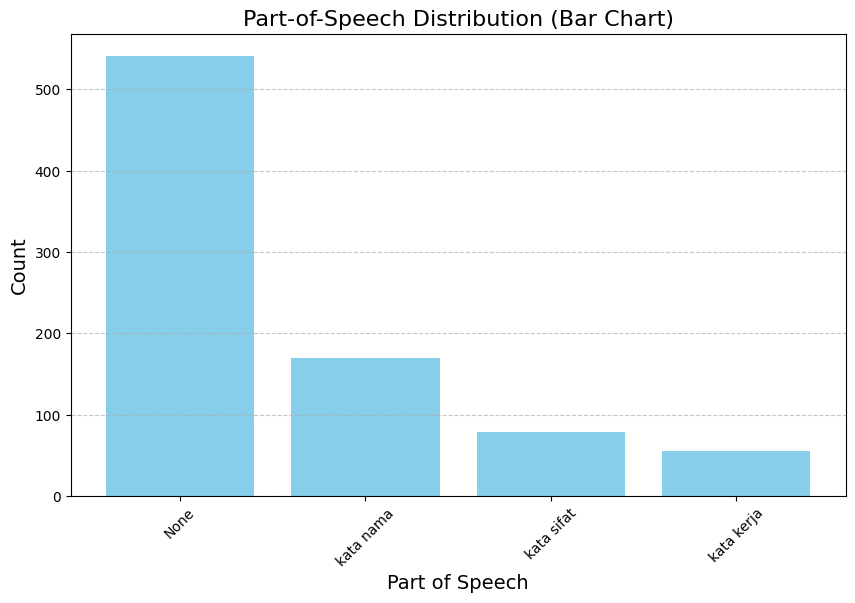

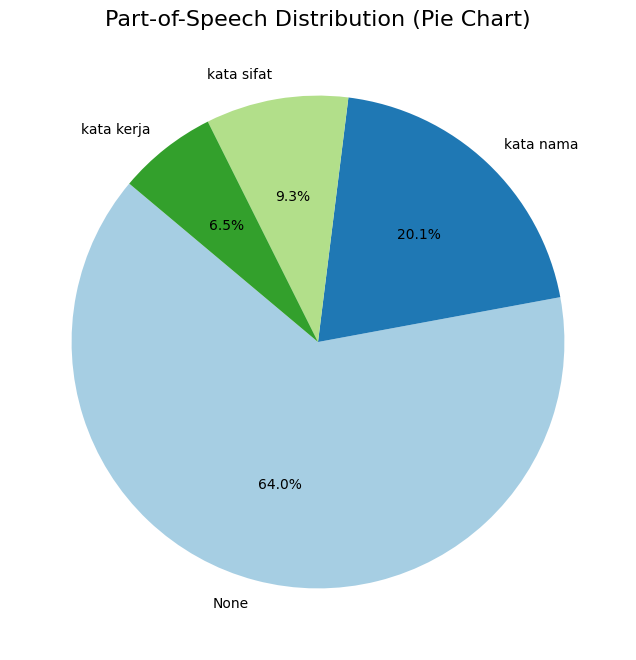

In [ ]:
from py2neo import Graph
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, lit
import matplotlib.pyplot as plt
import pandas as pd
import redis
import json  # For serializing/deserializing data in Redis

# Initialize PySpark session
spark = SparkSession.builder.appName("POSDistribution").getOrCreate()

# Connect to Redis
redis_client = redis.StrictRedis(host='localhost', port=6379, db=0)

# Function to fetch data from Redis or Neo4j
def get_data_from_redis_or_neo4j(redis_key, query, graph):
    # Check if data exists in Redis
    cached_data = redis_client.get(redis_key)
    if cached_data:
        print("Data fetched from Redis")
        # Deserialize JSON data from Redis
        return json.loads(cached_data)
    else:
        print("Fetching data from Neo4j")
        # Run the query in Neo4j
        data = graph.run(query).data()
        # Cache the data in Redis for future use
        redis_client.set(redis_key, json.dumps(data))
        return data

# Neo4j query to fetch words and parts of speech
query = """
MATCH (w:Word)
RETURN w.name AS word, COALESCE(w.part_of_speech, "None") AS part_of_speech
"""

# Redis key for caching
redis_key = "neo4j_pos_data"

# Retrieve data from Redis or Neo4j
graph = graph = Graph(URI, auth=())
 # Replace with your credentials
data = get_data_from_redis_or_neo4j(redis_key, query, graph)

# Convert data into a PySpark DataFrame
df = spark.createDataFrame(data)
df = df.fillna({"part_of_speech": "None"})
# Analyze the distribution of parts of speech
pos_distribution = (
    df.groupBy("part_of_speech")
    .count()
    .orderBy(col("count").desc())
)

# Calculate the total number of words for percentage distribution
total_words = df.count()
pos_distribution = pos_distribution.withColumn(
    "percentage",
    (col("count") / lit(total_words)) * 100
)

# Convert PySpark DataFrame to Pandas DataFrame for visualization
pos_distribution_pd = pos_distribution.toPandas()

# Cache the processed POS distribution to Redis
redis_client.set("pos_distribution", pos_distribution_pd.to_json())

# Visualization: Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(
    pos_distribution_pd["part_of_speech"],
    pos_distribution_pd["count"],
    color='skyblue'
)
plt.title("Part-of-Speech Distribution (Bar Chart)", fontsize=16)
plt.xlabel("Part of Speech", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualization: Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(
    pos_distribution_pd["percentage"],
    labels=pos_distribution_pd["part_of_speech"],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)
plt.title("Part-of-Speech Distribution (Pie Chart)", fontsize=16)
plt.show()


### 4.1.3 Synonym Network Graph

24/12/23 15:13:28 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Graph data not found in Redis. Fetching from Neo4j.
Graph data stored in Redis for future use.


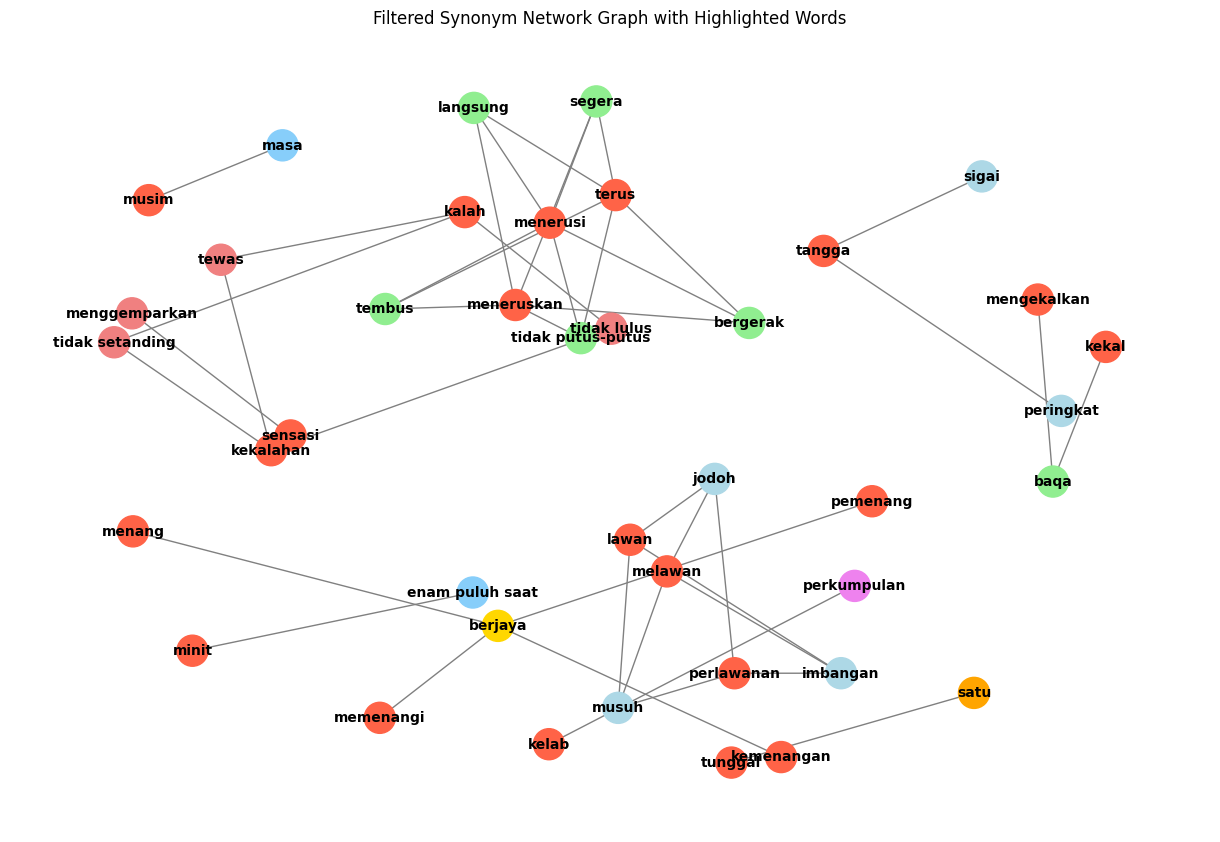

In [ ]:
import redis
from pyspark.sql import SparkSession
from py2neo import Graph
import networkx as nx
import matplotlib.pyplot as plt
from itertools import cycle
import pickle  # For serializing the graph to store in Redis

# Initialize Spark session
spark = SparkSession.builder \
    .appName("Synonym Network Analysis") \
    .getOrCreate()

# Connect to Neo4j 
graph = Graph(URI, auth=())

# Connect to Redis
redis_host = "localhost"
redis_port = 6379
r = redis.StrictRedis(host=redis_host, port=redis_port, db=0)

# Redis key to store the graph data
redis_key = "synonym_graph"

# Step 1: Try to retrieve the graph data from Redis
graph_data = r.get(redis_key)

def assign_colors(graph, word_nodes):
    """Assign colors to nodes based on connected components."""
    colors = cycle(['lightblue', 'lightgreen', 'lightcoral', 'lightskyblue', 'gold', 'violet', 'orange'])
    component_color_map = {}
    for component, color in zip(nx.connected_components(graph), colors):
        for node in component:
            component_color_map[node] = color

    word_node_color = 'tomato'
    node_colors = [
        word_node_color if node in word_nodes else component_color_map[node]
        for node in graph.nodes()
    ]
    return node_colors

if graph_data:
    print("Graph data found in Redis. Loading from cache.")
    # Deserialize the graph from Redis (load it back into a NetworkX graph)
    G_filtered = pickle.loads(graph_data)

    # Reconstruct word nodes
    word_nodes = {node for node, attr in G_filtered.nodes(data=True) if attr.get("label") == "Word"}
    # Assign consistent colors
    node_colors = assign_colors(G_filtered, word_nodes)
else:
    print("Graph data not found in Redis. Fetching from Neo4j.")
    
    # Query to retrieve Words, Synonyms, and their relationships
    query = """
    MATCH (w:Word)-[:HAS_SYNONYM]->(syn:Synonym)
    RETURN w.name AS Word, syn.name AS Synonym
    """
    
    # Execute the query and fetch data into a Pandas DataFrame
    synonym_data = graph.run(query).to_data_frame()

    # Convert to Spark DataFrame
    synonym_df = spark.createDataFrame(synonym_data)

    # Step 2: Prepare data for visualization
    # Limit the number of nodes/words
    filtered_synonyms = synonym_df.limit(20).collect()  # Collect the top 20 rows as a list

    # Step 3: Build the graph using NetworkX
    G_filtered = nx.Graph()
    word_nodes = set()

    for row in filtered_synonyms:
        word = row['Word']
        synonyms = row['Synonym'].split(',')
        G_filtered.add_node(word, label="Word")  # Add label for word nodes
        word_nodes.add(word)
        for synonym in synonyms:
            synonym = synonym.strip()
            G_filtered.add_edge(word, synonym)

    # Assign consistent colors
    node_colors = assign_colors(G_filtered, word_nodes)

    # Store the graph in Redis by serializing it
    r.set(redis_key, pickle.dumps(G_filtered))
    print("Graph data stored in Redis for future use.")

# Step 5: Visualize the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_filtered, k=0.8)

nx.draw(
    G_filtered, pos, with_labels=True, node_size=500, font_size=10,
    font_weight="bold", node_color=node_colors, edge_color="gray"
)
plt.title("Filtered Synonym Network Graph with Highlighted Words")
plt.show()

# Stop the Spark session
spark.stop()


### 4.1.4 Sentiment Distribution

24/12/23 15:20:46 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Sentiment data found in Redis. Loading from cache.
+----------------+-----+-------------------+
|SentimentalLabel|Count|         Proportion|
+----------------+-----+-------------------+
|        positive|  441| 0.5218934911242603|
|         neutral|  261| 0.3088757396449704|
|        negative|  143|0.16923076923076924|
+----------------+-----+-------------------+



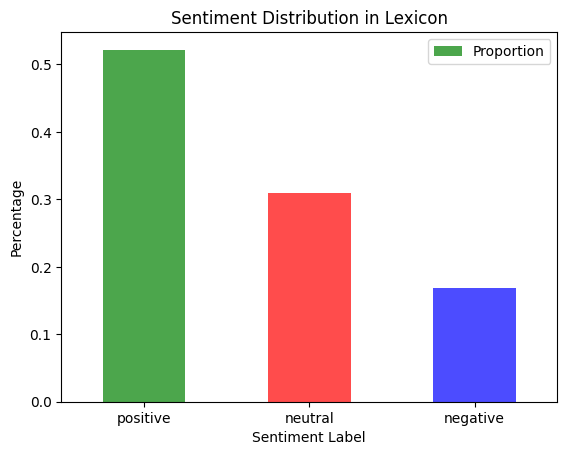

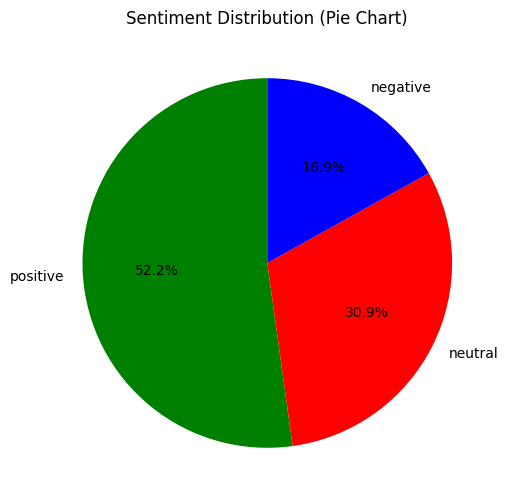

Dominant Emotional Tone: positive
Average Sentiment Score: 0.10
Sentiment Diversity (Shannon Entropy): 1.45


In [ ]:
import redis
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower, when, count
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType
from py2neo import Graph
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Neo4j Connection
graph = Graph("", auth=("neo4j", ""))

# Redis Connection
redis_host = "localhost"
redis_port = 6379
r = redis.StrictRedis(host=redis_host, port=redis_port, db=0)

# Redis key for storing the sentiment data
redis_key = "sentiment_data"

# Initialize Spark session
spark = SparkSession.builder \
    .appName("SentimentAnalysis") \
    .getOrCreate()

# Step 1: Try to retrieve the data from Redis
sentiment_data = r.get(redis_key)

if sentiment_data:
    print("Sentiment data found in Redis. Loading from cache.")
    # Deserialize the data from Redis
    sentiment_df = pickle.loads(sentiment_data)
    sentiment_df = spark.createDataFrame(sentiment_df)  # Convert back to Spark DataFrame
else:
    print("Sentiment data not found in Redis. Fetching from Neo4j.")
    
    # Query to retrieve sentiment-related data from Neo4j
    query = """
    MATCH (w:Word)
    WHERE w.`sentiment_score` IS NOT NULL
    RETURN w.name AS Name, w.sentiment_score AS SentimentScore, w.`sentimental_label` AS SentimentalLabel
    """

    # Execute query and load data into a Pandas DataFrame
    neo4j_data = graph.run(query).to_data_frame()
    print(neo4j_data.head())

    # Convert to Spark DataFrame
    sentiment_df = spark.createDataFrame(neo4j_data)

    # Step 2: Preprocess data on Spark DataFrame (before converting to Pandas)
    sentiment_df = sentiment_df.withColumn("SentimentalLabel", lower(col("SentimentalLabel")))

    sentiment_df = sentiment_df.withColumn(
        "SentimentalLabel",
        when(col("SentimentalLabel").isNull(), "neutral").otherwise(col("SentimentalLabel"))
    )

    # Convert the processed Spark DataFrame to Pandas DataFrame for Redis serialization
    pandas_sentiment_df = sentiment_df.toPandas()

    # Store data in Redis by serializing the Pandas DataFrame
    r.set(redis_key, pickle.dumps(pandas_sentiment_df))
    print("Sentiment data stored in Redis for future use.")

# Step 3: Group data by SentimentalLabel and calculate proportions
sentiment_distribution = sentiment_df.groupBy("SentimentalLabel") \
    .agg(count("*").alias("Count")) \
    .withColumn("Proportion", col("Count") / sentiment_df.count())

# Display the distribution as a table
sentiment_distribution.show()

# Step 4: Visualize the distribution (Bar Graph)
pandas_distribution = sentiment_distribution.toPandas()
pandas_distribution.plot(kind='bar', x="SentimentalLabel", y="Proportion", color=['green', 'red', 'blue'], alpha=0.7)
plt.title("Sentiment Distribution in Lexicon")
plt.xlabel("Sentiment Label")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

# Step 5: Create a Pie Chart for Sentiment Distribution
plt.figure(figsize=(6, 6))
pandas_distribution.set_index("SentimentalLabel", inplace=True)
pandas_distribution["Proportion"].plot(kind="pie", autopct='%1.1f%%', colors=['green', 'red', 'blue'], legend=False, startangle=90)
plt.title("Sentiment Distribution (Pie Chart)")
plt.ylabel("")
plt.show()

# Step 6: Calculate dominant sentiment for emotional tone
dominant_sentiment = sentiment_distribution.orderBy(col("Proportion").desc()).first()["SentimentalLabel"]
print(f"Dominant Emotional Tone: {dominant_sentiment}")

# Step 7: Calculate average sentiment score
sentiment_df = sentiment_df.withColumn("SentimentScore", col("SentimentScore").cast(FloatType()))
avg_sentiment_score = sentiment_df.select(F.mean("SentimentScore")).collect()[0][0]
print(f"Average Sentiment Score: {avg_sentiment_score:.2f}")


# Step 8: Calculate Shannon Entropy (Diversity)
proportions = pandas_distribution["Proportion"].values
diversity = entropy(proportions, base=2)
print(f"Sentiment Diversity (Shannon Entropy): {diversity:.2f}")



# Stop Spark session
spark.stop()


### 4.1.5 Word Length Complexity Analysis

24/12/23 15:13:41 WARN Utils: Service 'SparkUI' could not bind on port 4050. Attempting port 4051.


Word data not found in Redis. Fetching from Neo4j.


Word data stored in Redis for future use.
Average Word Length: 7.285207100591716
Word Length Distribution:
+-----------+-----+
|word_length|count|
+-----------+-----+
|          2|    4|
|          3|   16|
|          4|   65|
|          5|  137|
|          6|  107|
|          7|  143|
|          8|  129|
|          9|   94|
|         10|   65|
|         11|   55|
|         12|   19|
|         13|    7|
|         14|    3|
|         18|    1|
+-----------+-----+

Words with Length 2: ['ee', 'rm', 'ji', 'yu']
Words with Length 18: ['sekurang-kurangnya']


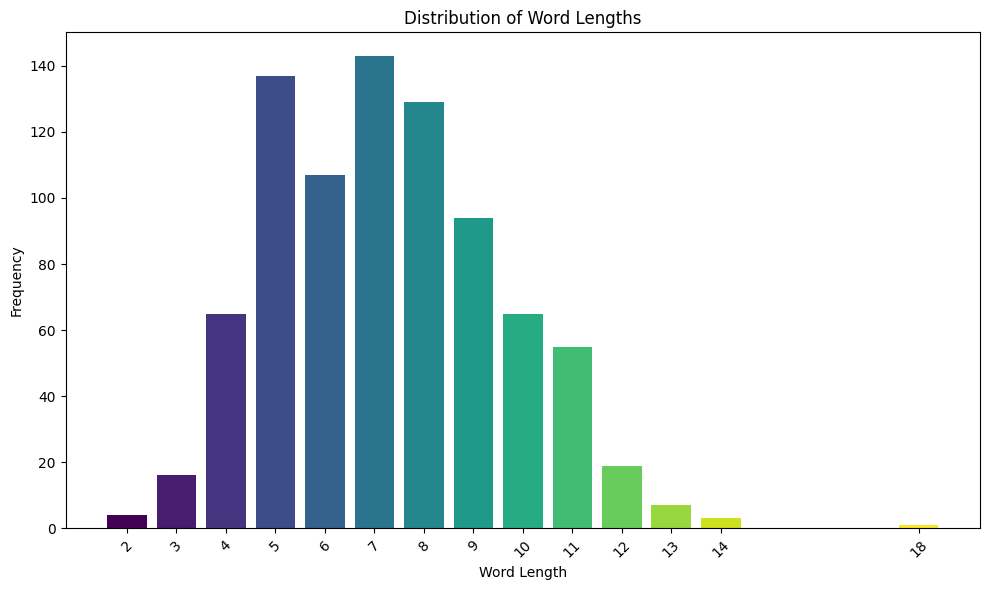

In [ ]:
import redis
from py2neo import Graph
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, length
import matplotlib.pyplot as plt
import numpy as np
import pickle

# Initialize Redis connection
redis_host = "localhost"
redis_port = 6379
r = redis.StrictRedis(host=redis_host, port=redis_port, db=0)

# Redis key for storing the word data
redis_key = "word_data"

# Initialize PySpark session
spark = SparkSession.builder.appName("WordLengthAnalysis").getOrCreate()

# Neo4j connection
graph = Graph("", auth=("neo4j", ""))

# Step 1: Try to retrieve the data from Redis
word_data = r.get(redis_key)

if word_data:
    print("Word data found in Redis. Loading from cache.")
    # Deserialize the data from Redis
    word_df = pickle.loads(word_data)
    word_df = spark.createDataFrame(word_df)  # Convert back to Spark DataFrame
else:
    print("Word data not found in Redis. Fetching from Neo4j.")
    
    # Query to retrieve word data from Neo4j
    query = """
    MATCH (w:Word)
    RETURN w.name AS word
    """
    data = graph.run(query).data()

    # Convert data into a PySpark DataFrame
    word_df = spark.createDataFrame(data)

    # Step 2: Add a new column for the length of each word
    word_df = word_df.withColumn("word_length", length(col("word")))

    # Step 3: Store the processed data in Redis (after converting to Pandas)
    word_df_pandas = word_df.toPandas()
    r.set(redis_key, pickle.dumps(word_df_pandas))  # Store the data in Redis
    print("Word data stored in Redis for future use.")

# Step 4: Calculate the average word length
average_word_length = word_df.agg({"word_length": "avg"}).collect()[0][0]
print(f"Average Word Length: {average_word_length}")

# Step 5: Analyze the distribution of word lengths
word_length_distribution = (
    word_df.groupBy("word_length")
    .count()
    .orderBy("word_length")
)

# Show the word length distribution
print("Word Length Distribution:")
word_length_distribution.show()

# Step 6: Filter and display words with a length of 2
words_length_2 = word_df.filter(col("word_length") == 2).select("word").collect()
words_length_2_list = [row["word"] for row in words_length_2]
print(f"Words with Length 2: {words_length_2_list}")

# Filter and display words with a length of 18
words_length_18 = word_df.filter(col("word_length") == 18).select("word").collect()
words_length_18_list = [row["word"] for row in words_length_18]
print(f"Words with Length 18: {words_length_18_list}")

# Step 7: Collect the results into a Pandas DataFrame for plotting
word_length_distribution_pd = word_length_distribution.toPandas()

# Create a color array using a colormap (one color for each bar)
colors = plt.cm.viridis(np.linspace(0, 1, len(word_length_distribution_pd)))

# Step 8: Plot the word length distribution using a bar chart with varying colors
plt.figure(figsize=(10, 6))
bars = plt.bar(word_length_distribution_pd['word_length'], word_length_distribution_pd['count'], color=colors)

# Ensure x-axis shows integers (no decimals)
plt.xticks(word_length_distribution_pd['word_length'].astype(int))  # Force integer display on x-axis

plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.title('Distribution of Word Lengths')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

# Stop Spark session
spark.stop()


## B. Intrinsic Evaluation

## Accuracy

In [ ]:
pip install googletrans==4.0.0-rc1 nltk neo4j


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install spacy


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Attempting uninstall: click
    Found existing installation: click 7.1.2
    Uninstalling click-7.1.2:
      Successfully uninstalled click-7.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
faust 1.10.4 requires click<8.0,>=6.7, but you have click 8.1.8 which is incompatible.
faust-streaming 0.11.3 requires venusian==3.1.0, but you have venusian 1.2.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
!python -m spacy download en_core_web_sm

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 9.6 MB/s eta 0:00:00ta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [ ]:
# Import the class
from accuracy_analysis import Neo4jProcessor
import pandas as pd

# Initialize the POSAnalysis class
processor = Neo4jProcessor()
# Fetch words with POS from Neo4j and translate them to English
word_list = processor.fetch_words_with_pos()
translations = processor.translate_words(word_list)

# Create a DataFrame from the translations
df_translations = pd.DataFrame(translations)
df_translations.head()
# Tag POS for the translated words
df_english = processor.tag_pos_spacy(df_translations)
df_english = df_english.drop(columns=["Translated Word"])

# Show the DataFrame with POS tags
df_english.head()
# Create Gold Standard DataFrame
gold_standard_df = processor.create_gold_standard_df()

# Show the Gold Standard DataFrame
gold_standard_df.head()
# Compare POS tags between Neo4j and Gold Standard
merged_df, total_words, correct_matches, accuracy = processor.compare_pos_with_gold_standard()

# Show comparison results and accuracy
print(f"Total Words Compared: {total_words}")
print(f"Correct Matches: {correct_matches}")
print(f"POS Accuracy: {accuracy:.2%}")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /home/student/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Error translating word 'suami': 'Translator' object has no attribute 'raise_Exception'
Error translating word 'isteri': 'Translator' object has no attribute 'raise_Exception'
Error translating word 'mengesahkan': 'Translator' object has no attribute 'raise_Exception'
Error translating word 'tempoh': 'Translator' object has no attribute 'raise_Exception'
Error translating word 'bersedia': 'Translator' object has no attribute 'raise_Exception'
Error translating word 'kempen': 'Translator' object has no attribute 'raise_Exception'
Error translating word 'perjanjian': 'Translator' object has no attribute 'raise_Exception'
Total Words Compared: 100
Correct Matches: 44
POS Accuracy: 44.00%


In [ ]:
# Import the class
from accuracy_analysis import Neo4jProcessor
import pandas as pd
# Define the Neo4j credentials and URI
URI = ""  # Replace with your actual URI
neo4j_user = ""
neo4j_password = ""  # Replace with your actual password

# Initialize the POSAnalysis class
processor = Neo4jProcessor(URI, )
# Fetch words with POS from Neo4j and translate them to English
word_list = processor.fetch_words_with_pos()
translations = processor.translate_words(word_list)

# Create a DataFrame from the translations
df_translations = pd.DataFrame(translations)
df_translations.head()
# Tag POS for the translated words
df_english = processor.tag_pos_spacy(df_translations)
df_english = df_english.drop(columns=["Translated Word"])

# Show the DataFrame with POS tags
df_english.head()
# Create Gold Standard DataFrame
gold_standard_df = processor.create_gold_standard_df()

# Show the Gold Standard DataFrame
gold_standard_df.head()
# Compare POS tags between Neo4j and Gold Standard
merged_df, total_words, correct_matches, accuracy = processor.compare_pos_with_gold_standard()

# Show comparison results and accuracy
print(f"Total Words Compared: {total_words}")
print(f"Correct Matches: {correct_matches}")
print(f"POS Accuracy: {accuracy:.2%}")

/home/student/de-prj/de-venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/student/de-prj/de-venv/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/student/de-prj/de-venv/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nl

Error translating word 'perjanjian': 'Translator' object has no attribute 'raise_Exception'
Total Words Compared: 100
Correct Matches: 44
POS Accuracy: 44.00%


In [ ]:
df_translations.head()

,Word,Translated Word,POS
0,tangga,stairs,PROPN
1,mengekalkan,preserve,PROPN
2,kalah,lose,PROPN
3,musim,season,PROPN
4,kemenangan,victory,PROPN


In [ ]:
df_english.head()

,Word,POS
0,tangga,PROPN
1,mengekalkan,PROPN
2,kalah,PROPN
3,musim,PROPN
4,kemenangan,PROPN


In [ ]:
gold_standard_df.head()

,Word,POS Malay
0,tangga,kata nama
1,mengekalkan,kata nama
2,kalah,kata nama
3,musim,kata nama
4,kemenangan,kata nama


## C. Extrinstic Evaluation

In [ ]:
# Test Data Frame
import pandas as pd
from transformers import pipeline

# Step 1: Load the HuggingFace Summarization Pipeline
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Step 2: Load the input CSV file
input_file = "sentence_with_sentiment.csv"  # Input file after emotion detection
data = pd.read_csv(input_file)

# Step 3: Verify if the required 'sentence' column exists
if 'sentence' not in data.columns:
    raise ValueError("Input CSV must contain a 'sentence' column.")

# Step 4: Limit the dataset to the first 40 rows
data = data.head(40)  # Or select based on other criteria

# Step 5: Add a new column for summarized text
data['Summary'] = None

# Step 6: Process each sentence to generate the summary
for index, row in data.iterrows():
    sentence = row['sentence']
    if pd.notna(sentence):  # Skip empty sentences
        try:
            # Generate a summary using HuggingFace summarization
            summary_result = summarizer(sentence, max_length=50, min_length=10, do_sample=False)
            summary = summary_result[0]['summary_text']  # Extract the summarized text
            data.at[index, 'Summary'] = summary
        except Exception as e:
            print(f"Error summarizing sentence at index {index}: {e}")
            data.at[index, 'Summary'] = sentence  # Fallback to the original sentence

# Step 7: Create a new DataFrame with only 'sentence' and 'Summary'
summarized_data = data[['sentence', 'Summary']]
print(summarized_data)

/home/student/de-prj/de-venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Your max_length is set to 50, but your input_length is only 42. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=21)
Your max_length is set to 50, but your input_length is only 43. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=21)
Your max_length is set to 50, but your input_length is only 22. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length man

                                             sentence  \
0   URL: https://www.sinarharian.com.my/article/70...   
1   Gol tunggal perlawanan dijelmakan menerusi pen...   
2   Girona beraksi di laman sendiri tampil agresif...   
3   Penjaga gol Liverpool, Alisson, membuat penamp...   
4   Separuh masa kedua, Liverpool yang menguasai p...   
5   "Enam kemenangan daripada enam perlawanan, and...   
6   "Ia tidak mudah untuk dilakukan atau akan ada ...   
7   "Sejujurnya, kami telah bermain jauh lebih bai...   
8   Sementara itu, pertahanan Girona, Alejandro Fr...   
9   "Sudah tiba masanya untuk meneruskan baki sain...   
10  Perkara utama ialah mempunyai peluang menentan...   
11  Liverpool tidak beraksi pada tahap terbaik mer...   
12  Kemenangan itu bermakna Liverpool meneruskan r...   
13  "Jika anda bertanya kepada saya tentang semua ...   
14  "Saya tidak berpuas hati dengan prestasi hari ...   
15  Kami berhak mendapat lebih daripada tiga mata ...   
16  Kami mempunyai penjaga gol 

In [ ]:
!python -m spacy download en_core_web_sm

In [ ]:
import pandas as pd
from transformers import pipeline
import spacy

# Step 1: Load the HuggingFace Summarization Pipeline
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Step 2: Load the input CSV file
input_file = "sentence_with_sentiment.csv"  
data = pd.read_csv(input_file)

# Step 3: Verify if the required 'sentence' column exists
if 'sentence' not in data.columns:
    raise ValueError("Input CSV must contain a 'sentence' column.")

# Step 4: Limit the dataset to the first 10 rows for demonstration
data = data.head(40)

# Step 5: Add a new column for summarized text
data['Summary'] = None

# Step 6: Process each sentence to generate the summary
for index, row in data.iterrows():
    sentence = row['sentence']
    if pd.notna(sentence):  # Skip empty sentences
        try:
            # Generate a summary using HuggingFace summarization
            summary_result = summarizer(sentence, max_length=50, min_length=10, do_sample=False)
            summary = summary_result[0]['summary_text']  # Extract the summarized text
            data.at[index, 'Summary'] = summary
        except Exception as e:
            print(f"Error summarizing sentence at index {index}: {e}")
            data.at[index, 'Summary'] = sentence  # Fallback to the original sentence

# Step 7: Create a new DataFrame with only 'sentence' and 'Summary'
summarized_data = data[['sentence', 'Summary']]
print(summarized_data)

# Step 8: Load reference summaries
reference_df = pd.read_csv('sentence_with_reference_summary.csv')

# Rename columns for clarity
summarized_data.rename(columns={'Summary': 'generated_summary'}, inplace=True)

# Merge summarized_data and reference_df based on 'sentence' column
merged_df = pd.merge(summarized_data, reference_df, on='sentence', how='inner')

# Display the merged DataFrame
#print(merged_df)

# Load the SpaCy model for tokenization
nlp = spacy.load('en_core_web_sm')

# Tokenize text
def tokenize(text):
    return [token.text.lower() for token in nlp(text) if not token.is_stop and not token.is_punct]

# Apply tokenization
merged_df['tokenized_summary'] = merged_df['generated_summary'].apply(tokenize)
merged_df['tokenized_reference_summary'] = merged_df['reference_summary'].apply(tokenize)

# Reset indices for merged data
merged_df.reset_index(drop=True, inplace=True)

# Function to generate n-grams
def generate_ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))

# Function to compute precision, recall, and F1-score
def compute_precision_recall_f1(pred_tokens, ref_tokens):
    pred_set = set(pred_tokens)
    ref_set = set(ref_tokens)
    intersection = pred_set.intersection(ref_set)
    
    precision = len(intersection) / len(pred_set) if pred_set else 0.0
    recall = len(intersection) / len(ref_set) if ref_set else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return precision, recall, f1

# Set n to 2 for bigrams
n = 2

# Store results for trigrams
results = []

# Loop through each pair of generated and reference summaries
for idx, row in merged_df.iterrows():
    generated_tokens = row['tokenized_summary']
    reference_tokens = row['tokenized_reference_summary']
    
    # Generate trigrams
    generated_trigrams = generate_ngrams(generated_tokens, n)
    reference_trigrams = generate_ngrams(reference_tokens, n)
    
    # Compute metrics
    precision, recall, f1 = compute_precision_recall_f1(generated_trigrams, reference_trigrams)
    
    # Store the results
    results.append({'precision': precision, 'recall': recall, 'f1': f1})

# Convert results into a DataFrame
metrics_df = pd.DataFrame(results)

# Calculate average Precision, Recall, and F1 across all samples
avg_precision = metrics_df['precision'].mean()
avg_recall = metrics_df['recall'].mean()
avg_f1 = metrics_df['f1'].mean()

# Print metrics for bigrams
print(f"Bigram Metrics:")
print(f"Average Precision: {avg_precision}")
print(f"Average Recall: {avg_recall}")
print(f"Average F1: {avg_f1}")

/home/student/de-prj/de-venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Your max_length is set to 50, but your input_length is only 42. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=21)
Your max_length is set to 50, but your input_length is only 43. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=21)
Your max_length is set to 50, but your input_length is only 22. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length man

                                             sentence  \
0   URL: https://www.sinarharian.com.my/article/70...   
1   Gol tunggal perlawanan dijelmakan menerusi pen...   
2   Girona beraksi di laman sendiri tampil agresif...   
3   Penjaga gol Liverpool, Alisson, membuat penamp...   
4   Separuh masa kedua, Liverpool yang menguasai p...   
5   "Enam kemenangan daripada enam perlawanan, and...   
6   "Ia tidak mudah untuk dilakukan atau akan ada ...   
7   "Sejujurnya, kami telah bermain jauh lebih bai...   
8   Sementara itu, pertahanan Girona, Alejandro Fr...   
9   "Sudah tiba masanya untuk meneruskan baki sain...   
10  Perkara utama ialah mempunyai peluang menentan...   
11  Liverpool tidak beraksi pada tahap terbaik mer...   
12  Kemenangan itu bermakna Liverpool meneruskan r...   
13  "Jika anda bertanya kepada saya tentang semua ...   
14  "Saya tidak berpuas hati dengan prestasi hari ...   
15  Kami berhak mendapat lebih daripada tiga mata ...   
16  Kami mempunyai penjaga gol 

/tmp/ipykernel_2458205/906305573.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summarized_data.rename(columns={'Summary': 'generated_summary'}, inplace=True)


Bigram Metrics:
Average Precision: 0.2763643099246815
Average Recall: 0.24143312346408322
Average F1: 0.25278953630131396


In [ ]:
# Stop the Spark session
spark.stop()
print("Spark session stopped")

Spark session stopped


# 5.0 Maintenance

In [ ]:
from data_collector import URLGenerator
from new_data_collector import DataCollector, process_article, load_crawled_urls, save_articles_to_file
from pyspark.sql import SparkSession

spark = SparkSession.builder \
        .appName("PySpark Data Collector") \
        .config("spark.ui.port", "4050") \
        .getOrCreate()

base_url = "https://www.sinarharian.com.my/article/"
url_generator = URLGenerator(base_url)
collector = DataCollector()

start_id = 701599
end_id = 701778

# Load previously crawled URLs
crawled_file = "articles_crawled.txt"
crawled_urls = load_crawled_urls(crawled_file)

# Parallelize IDs
article_ids = spark.sparkContext.parallelize(range(start_id, end_id + 1))
articles = article_ids.map(lambda article_id: process_article(article_id, url_generator, collector, crawled_urls))

# Collect new articles
new_articles = articles.filter(lambda x: x is not None).collect()

if new_articles:
    # Append new articles to the main file
    save_articles_to_file(new_articles, crawled_file, append=True)

# Save new articles separately
    new_crawled_file = "new_articles_crawled.txt"
    save_articles_to_file(new_articles, new_crawled_file, append=False)

    print(f"Data collection completed. Found {len(new_articles)} new 'Sukan' articles.")
    print(f"New 'Sukan' articles successfully append to 'articles_crawled.txt'.")
    print(f"New 'Sukan' articles successfully save to 'new_articles_crawled.txt'.")
else:
    print("No new 'Sukan' articles found.")

spark.stop()



24/12/23 15:34:05 WARN Utils: Service 'SparkUI' could not bind on port 4050. Attempting port 4051.
                                                                                

Data collection completed. Found 2 new 'Sukan' articles.
New 'Sukan' articles successfully append to 'articles_crawled.txt'.
New 'Sukan' articles successfully save to 'new_articles_crawled.txt'.


### Put txt into Hadoop Environment

In [ ]:
!hdfs dfs -put -f /home/student/new_articles_crawled.txt /user/student/new_articles_crawled.txt

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
#Retrieve the File from HDFS into PySpark DataFrame
from pyspark.sql import SparkSession

# Initialize Spark session
spark = SparkSession.builder \
    .appName("HDFS File Retrieval and Data Processing") \
    .getOrCreate()

# Set the HDFS file path
hdfs_path = "hdfs://localhost:9000/user/student/new_articles_crawled.txt"

# Read the file from HDFS into a DataFrame
df = spark.read.text(hdfs_path)

# Show the first few rows of the DataFrame to inspect the data
df.show(20)


24/12/23 15:34:32 WARN Utils: Service 'SparkUI' could not bind on port 4050. Attempting port 4051.


+--------------------+
|               value|
+--------------------+
|URL: https://www....|
|Title: Speedy Tig...|
|                    |
|            Content:|
|SKUAD hoki lelaki...|
|Walaupun kejohana...|
|Perkembangan ters...|
|“Dari segi persem...|
|“Kita perlu terus...|
|Kejohanan Hoki Pi...|
|Sebagai rekod, ke...|
|“Sebelum ini saya...|
|                    |
|Sejak Kejohanan H...|
|-----------------...|
|URL: https://www....|
|Title: Arab Saudi...|
|                    |
|            Content:|
|KEJOHANAN bola se...|
+--------------------+
only showing top 20 rows



In [ ]:
from data_cleaner import DataCleaner

# Initialize and use DataCleaner
cleaner = DataCleaner()

# Step 1: Clean Data
cleaned_df = cleaner.clean_data(df)

# Step 2: Format Data
 # Convert DataFrame to RDD and process it
formatted_df = cleaner.format_data(cleaned_df)
print("Formatted DataFrame:")
data_preview = formatted_df.take(10)  # Retrieve first 10 records
for row in data_preview:
    print(row["combined_text"])


[Stage 1:>                                                          (0 + 1) / 1]

Formatted DataFrame:
speedy tigers bersiap awal ke india skuad hoki lelaki negara tekad memperbaiki segala kelemahan untuk berada pada prestasi terbaik menjelang kejohanan hoki piala asia di india tahun depan walaupun kejohanan dijadualkan pada ogos namun skuad speedy tigers giat menjalani latihan memperkasakan pasukan bagi mencuri slot ke piala dunia perkembangan tersebut dikongsi pemain negara shello silverius yang turut bertekad memperagakan aksi terbaik sekiranya diberi peluang menyertai skuad bimbingan sarjit singh itu dari segi persembahan memang kurang baik tahun ini kita sudah menganalisis kelemahan pasukan dan tahun depan kita akan buat lebih baik kita perlu teruskan latihan dan meningkatkan prestasi lebih baik untuk kejohanan akan datang katanya kejohanan hoki piala asia dijadual berlangsung di rajgir bermula ogos hingga september depan sebagai rekod ketika beraksi bersama skuad negara kendalian arul selvaraj pada piala dunia shello meledak tiga jaringan dalam kejohanan terse

In [ ]:
from data_processor import DataProcessor
# Instantiate the DataProcessor class
processor = DataProcessor()

# Process the data using the instance
final_df, tokenized_df, df_without_stopwords, minus_df = processor.process_data(formatted_df)

# Display the results
data_preview = final_df.select("tokens_excluded").take(10)
for row in data_preview:
    print(row["tokens_excluded"])

[nltk_data] Downloading package words to /home/student/nltk_data...
[nltk_data]   Package words is already up-to-date!
[Stage 3:>                                                          (0 + 1) / 1]

['tigers', 'bersiap', 'awal', 'india', 'skuad', 'hoki', 'lelaki', 'negara', 'tekad', 'memperbaiki', 'segala', 'kelemahan', 'berada', 'prestasi', 'terbaik', 'menjelang', 'kejohanan', 'piala', 'asia', 'tahun', 'depan', 'walaupun', 'dijadualkan', 'ogos', 'giat', 'menjalani', 'latihan', 'memperkasakan', 'pasukan', 'mencuri', 'dunia', 'perkembangan', 'tersebut', 'dikongsi', 'pemain', 'shello', 'silverius', 'turut', 'bertekad', 'memperagakan', 'aksi', 'sekiranya', 'diberi', 'peluang', 'menyertai', 'bimbingan', 'sarjit', 'segi', 'persembahan', 'memang', 'kurang', 'baik', 'menganalisis', 'buat', 'lebih', 'perlu', 'teruskan', 'meningkatkan', 'datang', 'katanya', 'dijadual', 'berlangsung', 'rajgir', 'bermula', 'hingga', 'september', 'rekod', 'beraksi', 'bersama', 'kendalian', 'arul', 'selvaraj', 'meledak', 'tiga', 'jaringan', 'terlibat', 'kelayakan', 'sasar', 'layak', 'sekali', 'ujar', 'sejak', 'malaysia', 'pernah', 'sembilan', 'pencapaian', 'meraih', 'tempat', 'keempat', 'menjadi', 'rumah', 'ar

In [ ]:
from data_exporter import DataExporter

# Assuming spark is already initialized and final_df is available
exporter = DataExporter(spark)

# Step 1: Flatten tokens from the final DataFrame
flattened_tokens = exporter.flatten_tokens(final_df)

# Step 2: Create a DataFrame from the flattened tokens
tokens_df = exporter.create_tokens_df(flattened_tokens)

# Step 3: Define the output path
output_path = "all_tokens.txt"

# Step 4: Delete the output path if it exists
exporter.delete_if_exists(output_path)

# Step 5: Export the tokens to a text file
exporter.export_tokens(tokens_df, output_path)

[Stage 5:>                                                          (0 + 1) / 1]

Tokens exported to all_tokens.txt


## Import into MongoDB

In [ ]:
from lexicon_creation import HDFSToMongoDB

# Define variables
hdfs_path = ""
mongo_uri = ""
db_name = ""
collection_name = ""
object_id = ""

# Step 1: Initialize the class
hdfs_mongo = HDFSToMongoDB(hdfs_path, mongo_uri, db_name, collection_name, object_id)

# Step 2: Start Spark session
hdfs_mongo.initialize_spark()

# Step 3: Read tokens from HDFS into RDD
tokens_array = hdfs_mongo.read_txt_file()

filtered_tokens = hdfs_mongo.filter_tokens(tokens_array)

# Step 4: Update MongoDB (append mode)
result_message = hdfs_mongo.append_mongodb(filtered_tokens)
print(result_message)

# Step 5: Stop Spark session
hdfs_mongo.stop_spark()

24/12/23 15:35:04 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Added 90 new tokens to the existing document in MongoDB!


## Annotation

In [ ]:
import malaya
import pymongo

# Initialize the MongoDB client and collection
client = pymongo.MongoClient("")
db = client["my_database"]  # Replace with your database name
collection = db["tokens_collection"]  # Replace with your collection name

# Retrieve the document with tokens (assuming there's only one document)
document = collection.find_one()

# Extract the tokens array from the MongoDB document
tokens_array = document.get("tokens", [])

# Load the HuggingFace-based sentiment model
sentiment_model = malaya.sentiment.huggingface()

# Load the POS tagging model (if available)
pos_model = malaya.pos.huggingface()  # This should work if the model is available

# POS tag map for Malay
pos_tag_map_malay = {
    'PROPN': 'Nama Khas',
    'NOUN': 'Kata Nama',
    'ADP': 'Kata Sendi',
    'VERB': 'Kata Kerja',
    'ADJ': 'Kata Sifat',
    'ADV': 'Kata Keterangan',
    'PRON': 'Kata Ganti Nama',
    'DET': 'Kata Penentu',
    'NUM': 'Kata Bilangan',
    'PART': 'Partikel',
    'SYM': 'Simbol',
    'X': 'Lain-lain'
}

# Step 1: Track the first position (index) of a token with missing sentiment and pos
missing_sentiment_pos_index = None  # Initialize as None

updated_tokens = []

for index, token in enumerate(tokens_array):
    # If token is a string (missing sentiment and pos), treat it as a dictionary
    if isinstance(token, str):
        token = {'word': token}
    
    # Ensure the token is a dictionary and check if sentiment or POS is missing
    if 'sentiment' not in token or 'pos' not in token:
        # If the first missing sentiment or pos is found, record the index
        if missing_sentiment_pos_index is None:
            missing_sentiment_pos_index = index
        
        word_str = str(token['word'])
        
        # Sentiment prediction for the word (as a single string)
        sentiment = sentiment_model.predict([word_str])[0]  # Predict sentiment for the word
        
        # POS prediction (pass word as a string and get the POS tags)
        pos_tags = pos_model.predict(word_str)  # POS result for the word
        pos_tag = pos_tags[0][1] if pos_tags else "Unknown"  # Get the POS tag for the word
        readable_pos = pos_tag_map_malay.get(pos_tag, "Unknown")  # Translate POS tag to Malay
        
        # Update the token with predicted sentiment and POS
        token['sentiment'] = sentiment
        token['pos'] = readable_pos
    
    # Add the updated or existing token to the list
    updated_tokens.append(token)

# Step 2: Save the annotated data back to MongoDB
annotated_document = {
    "tokens": updated_tokens
}

# Insert or update the annotated data in the collection
collection.update_one({"_id": document["_id"]}, {"$set": annotated_document})

# Step 3: Print the first index position with missing sentiment and POS
if missing_sentiment_pos_index is not None:
    print(f"First index position with missing sentiment and POS: {missing_sentiment_pos_index}")
else:
    print("No tokens with missing sentiment and POS found.")

print("Annotation completed and data updated in MongoDB.")



/home/student/de-prj/de-venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


First index position with missing sentiment and POS: 1191
Annotation completed and data updated in MongoDB.


# 3. Lexicon Enrichment 

In [ ]:
from pyspark.sql import SparkSession
from lexicon_scraper1 import get_words_from_mongo_by_id, scrape_DBP_data, write_to_csv, Lexicon, get_words_from_mongo

# Initialize Spark session
spark = SparkSession.builder \
    .appName("Lexicon Scraper") \
    .getOrCreate()

# ObjectId to fetch the document
object_id = "675f06d4b3722385e1799433"

print(missing_sentiment_pos_index)

# Get words from MongoDB by ObjectId
words = get_words_from_mongo(missing_sentiment_pos_index)

if not words:
    print("No words found for the given missing_sentiment_pos_index.")
else:
    # Parallelize the list of words using PySpark
    rdd = spark.sparkContext.parallelize(words)

    # Process each word in parallel
    def process_word(word):
        lexicon_entry = scrape_DBP_data(word)
        if lexicon_entry:
            return {
                "word": lexicon_entry.word,
                "stemmed_word": ''.join(lexicon_entry.stemmed_word or []),
                "definitions": '; '.join(lexicon_entry.definitions or []),
                "part_of_speech": lexicon_entry.part_of_speech,
                "contexts": '; '.join(lexicon_entry.contexts or []),
                "synonyms": '; '.join(lexicon_entry.synonyms or []),
                "antonyms": '; '.join(lexicon_entry.antonyms or []),
                "derived_words": ', '.join(lexicon_entry.derived_words or [])
            }
        return None

    # Map the process_word function to each word
    lexicon_rdd = rdd.map(process_word).filter(lambda x: x is not None)

    # Collect the processed data
    lexicon_data = lexicon_rdd.collect()

    if not lexicon_data:
        print("No lexicon data was scraped.")
    else:
        # Save to CSV
        output_filename = "lexicon_data.csv"
        write_to_csv(output_filename, [
            Lexicon(
                word=data["word"],
                stemmed_word=data["stemmed_word"],
                definitions=data["definitions"].split("; "),
                part_of_speech=data["part_of_speech"],
                contexts=data["contexts"].split("; "),
                synonyms=data["synonyms"].split("; "),
                antonyms=data["antonyms"].split("; "),
                derived_words=data["derived_words"].split(", ")
            ) for data in lexicon_data
        ])
        print(f"Data successfully written to {output_filename}")

# Stop Spark session
spark.stop()


24/12/23 15:35:47 WARN Utils: Service 'SparkUI' could not bind on port 4050. Attempting port 4051.


1191


[Stage 0:>                                                        (0 + 18) / 18]INFO:root:Scraping data for dikongsi...
INFO:root:Scraping data for tigers...
INFO:root:Scraping data for uruguay...
INFO:root:Scraping data for diwakili...
INFO:root:Scraping data for memaklumkan...
INFO:root:Scraping data for efektif...
INFO:root:Scraping data for pemerhatian...
INFO:root:Scraping data for selvaraj...
INFO:root:Scraping data for maghribi...
INFO:root:Scraping data for kelemahan...
INFO:root:Scraping data for penambahbaikan...
INFO:root:Scraping data for proses...
INFO:root:Scraping data for minyak...
INFO:root:Scraping data for sportswashing...
INFO:root:Scraping data for sarjit...
INFO:root:Scraping data for tepuk...
INFO:root:Scraping data for memperingati...
INFO:root:Scraping data for bersiap...
INFO:root:Scraping data for sembilan...
INFO:root:Scraping data for pautan...
INFO:root:Scraping data for shello...
INFO:root:Scraping data for manusia...
INFO:root:Scraping data for jesper...

Data successfully written to lexicon_data.csv


# Hypernyms and Hyponyms

In [ ]:
import pandas as pd
from nltk.corpus import wordnet

# Read the dataset
data = pd.read_csv("lexicon_data.csv")
data['Hypernyms'] = ''
data['Hyponyms'] = ''
data['Meronyms'] = ''
data['Holonyms'] = ''

# Define function to get Hypernyms, Hyponyms, Meronyms, and Holonyms in Malay
def get_hypernyms_hyponyms_meronyms_holonyms_in_malay(word):
    hypernyms = []
    hyponyms = []
    meronyms = []
    holonyms = []
    
    try:
        for synset in wordnet.synsets(word, lang='zsm'):  # Ensure it works for Malay
            # Hypernyms
            hypernyms.extend([lemma.name() for synset in synset.hypernyms() for lemma in synset.lemmas(lang='zsm')])
            # Hyponyms
            hyponyms.extend([lemma.name() for synset in synset.hyponyms() for lemma in synset.lemmas(lang='zsm')])
            # Meronyms
            meronyms.extend([lemma.name() for synset in synset.part_meronyms() + synset.substance_meronyms() + synset.member_meronyms() for lemma in synset.lemmas(lang='zsm')])
            # Holonyms
            holonyms.extend([lemma.name() for synset in synset.part_holonyms() + synset.substance_holonyms() + synset.member_holonyms() for lemma in synset.lemmas(lang='zsm')])
        
        # Use set to remove duplicates and limit to 3 words for each relation
        hypernyms = ', '.join(list(set(hypernyms))[:3])
        hyponyms = ', '.join(list(set(hyponyms))[:3])
        meronyms = ', '.join(list(set(meronyms))[:3])
        holonyms = ', '.join(list(set(holonyms))[:3])
    
    except Exception as e:
        print(f"Error processing word {word}: {e}")
        return "[]", "[]", "[]", "[]"
    
    return hypernyms, hyponyms, meronyms, holonyms

# Process each word in the dataset
for index, row in data.iterrows():
    word = row['Word']  # Adjust column name if necessary
    hypernyms, hyponyms, meronyms, holonyms = get_hypernyms_hyponyms_meronyms_holonyms_in_malay(word)
    data.loc[index, 'Hypernyms'] = hypernyms
    data.loc[index, 'Hyponyms'] = hyponyms
    data.loc[index, 'Meronyms'] = meronyms
    data.loc[index, 'Holonyms'] = holonyms

# Export the updated dataset to the same CSV file (overwrite)
data.to_csv("lexicon_data.csv", index=False, encoding='utf-8')

import pandas as pd
df = pd.read_csv('lexicon_data.csv')
df.head(5)

,Word,Stemmed Word,Definitions,Part of Speech,Contexts,Synonyms,Antonyms,Derived Words,Hypernyms,Hyponyms,Meronyms,Holonyms
0,bersiap,siap,[ber.siap] | برسياڤ Definisi : Id jaga sedia!...,kata kerja,NaN,selesai,NaN,"bersiap, bersiap-siap, menyiapkan, persiapan, ...","berubah, malih, persiapan","terbenam, berlatih, membina",NaN,NaN
1,india,NaN,Definisi : bangsa yg nenek moyang mereka beras...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sungai_Ganges, Calcutta, Kashmir","Asia, Negara-Negara_Komanwel, OPEC"
2,tekad,tekad,[té.kad] | تيکد Definisi : (tékad) kemahuan y...,kata nama,NaN,kebulatan hati,NaN,bertekad,"kualiti, tegas, ketegasan","kerajinan, ketekunan, kegigihan",NaN,NaN
3,memperbaiki,NaN,[mem.per.bai.ki]/[mem.per.bai/.ki] | ممڤرباءي...,NaN,NaN,NaN,NaN,NaN,"berubah, menaksir, membayar_kembali","berubah, mendirikan, merenjong",NaN,NaN
4,kelemahan,lemah,[ke.le.ma.han] | کلمهن Definisi : perihal lem...,kata sifat,NaN,"lesu, lembam","cergas, cerdas","melemahkan, kelemahan","kekurangan, kecacatan, keistimewaan","kekurangan, lesu, tiada",NaN,NaN


In [ ]:
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType, StructType, StructField

from nltk.corpus import wordnet
from lexicon_scraper2 import get_hypernyms_hyponyms_meronyms_holonyms_in_malay

# Read the dataset
data = pd.read_csv("lexicon_data.csv")
data['Hypernyms'] = ''
data['Hyponyms'] = ''
data['Meronyms'] = ''
data['Holonyms'] = ''

# Process each word in the dataset
for index, row in data.iterrows():
    word = row['Word']  # Adjust column name if necessary
    hypernyms, hyponyms, meronyms, holonyms = get_hypernyms_hyponyms_meronyms_holonyms_in_malay(word)
    data.loc[index, 'Hypernyms'] = hypernyms
    data.loc[index, 'Hyponyms'] = hyponyms
    data.loc[index, 'Meronyms'] = meronyms
    data.loc[index, 'Holonyms'] = holonyms

# Export the updated dataset to the same CSV file (overwrite)
data.to_csv("lexicon_data.csv", index=False, encoding='utf-8')

import pandas as pd
df = pd.read_csv('lexicon_data.csv')
df.head(5)



,Word,Stemmed Word,Definitions,Part of Speech,Contexts,Synonyms,Antonyms,Derived Words,Hypernyms,Hyponyms,Meronyms,Holonyms
0,bersiap,siap,[ber.siap] | برسياڤ Definisi : Id jaga sedia!...,kata kerja,NaN,selesai,NaN,"bersiap, bersiap-siap, menyiapkan, persiapan, ...","berubah, malih, persiapan","terbenam, berlatih, membina",NaN,NaN
1,india,NaN,Definisi : bangsa yg nenek moyang mereka beras...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sungai_Ganges, Calcutta, Kashmir","Asia, Negara-Negara_Komanwel, OPEC"
2,tekad,tekad,[té.kad] | تيکد Definisi : (tékad) kemahuan y...,kata nama,NaN,kebulatan hati,NaN,bertekad,"kualiti, tegas, ketegasan","kerajinan, ketekunan, kegigihan",NaN,NaN
3,memperbaiki,NaN,[mem.per.bai.ki]/[mem.per.bai/.ki] | ممڤرباءي...,NaN,NaN,NaN,NaN,NaN,"berubah, menaksir, membayar_kembali","berubah, mendirikan, merenjong",NaN,NaN
4,kelemahan,lemah,[ke.le.ma.han] | کلمهن Definisi : perihal lem...,kata sifat,NaN,"lesu, lembam","cergas, cerdas","melemahkan, kelemahan","kekurangan, kecacatan, keistimewaan","kekurangan, lesu, tiada",NaN,NaN


In [ ]:
from sentiment_labelling import SentimentLabelling
import pandas as pd

# Instantiate the SentimentLabelling class
sentiment_analyzer = SentimentLabelling()

# Load your dataset
data = pd.read_csv("lexicon_data.csv", encoding='utf-8')

# Apply sentiment analysis and add the score column
data['Sentiment_Score'] = data['Word'].apply(sentiment_analyzer.analyze_sentiment)

# Save the results
data.to_csv("lexicon_data.csv", index=False, encoding='utf-8')

print("Sentiment scores added successfully!")

# Load the updated CSV and display the first 5 rows
df = pd.read_csv('lexicon_data.csv')
df.head(5)# Initialize Spark session


/home/student/de-prj/de-venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/student/de-prj/de-venv/lib/python3.10/site-packages/transformers/modeling_utils.py:519: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlis

Sentiment scores added successfully!


,Word,Stemmed Word,Definitions,Part of Speech,Contexts,Synonyms,Antonyms,Derived Words,Hypernyms,Hyponyms,Meronyms,Holonyms,Sentiment_Score
0,bersiap,siap,[ber.siap] | برسياڤ Definisi : Id jaga sedia!...,kata kerja,NaN,selesai,NaN,"bersiap, bersiap-siap, menyiapkan, persiapan, ...","berubah, malih, persiapan","terbenam, berlatih, membina",NaN,NaN,0.000000
1,india,NaN,Definisi : bangsa yg nenek moyang mereka beras...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sungai_Ganges, Calcutta, Kashmir","Asia, Negara-Negara_Komanwel, OPEC",0.116055
2,tekad,tekad,[té.kad] | تيکد Definisi : (tékad) kemahuan y...,kata nama,NaN,kebulatan hati,NaN,bertekad,"kualiti, tegas, ketegasan","kerajinan, ketekunan, kegigihan",NaN,NaN,0.000000
3,memperbaiki,NaN,[mem.per.bai.ki]/[mem.per.bai/.ki] | ممڤرباءي...,NaN,NaN,NaN,NaN,NaN,"berubah, menaksir, membayar_kembali","berubah, mendirikan, merenjong",NaN,NaN,0.000000
4,kelemahan,lemah,[ke.le.ma.han] | کلمهن Definisi : perihal lem...,kata sifat,NaN,"lesu, lembam","cergas, cerdas","melemahkan, kelemahan","kekurangan, kecacatan, keistimewaan","kekurangan, lesu, tiada",NaN,NaN,0.383738


In [ ]:
# Add the Sentimental_Label column based on the Sentiment_Score
data['Sentimental_Label'] = data['Sentiment_Score'].apply(sentiment_analyzer.assign_sentimental_label)

# Save the results
data.to_csv("lexicon_data.csv", index=False, encoding='utf-8')

print("Sentiment labels added successfully!")

# Load the updated CSV and display the first 5 rows
df = pd.read_csv('lexicon_data.csv')
df.head(5)


Sentiment labels added successfully!


,Word,Stemmed Word,Definitions,Part of Speech,Contexts,Synonyms,Antonyms,Derived Words,Hypernyms,Hyponyms,Meronyms,Holonyms,Sentiment_Score,Sentimental_Label
0,bersiap,siap,[ber.siap] | برسياڤ Definisi : Id jaga sedia!...,kata kerja,NaN,selesai,NaN,"bersiap, bersiap-siap, menyiapkan, persiapan, ...","berubah, malih, persiapan","terbenam, berlatih, membina",NaN,NaN,0.000000,Neutral
1,india,NaN,Definisi : bangsa yg nenek moyang mereka beras...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sungai_Ganges, Calcutta, Kashmir","Asia, Negara-Negara_Komanwel, OPEC",0.116055,Positive
2,tekad,tekad,[té.kad] | تيکد Definisi : (tékad) kemahuan y...,kata nama,NaN,kebulatan hati,NaN,bertekad,"kualiti, tegas, ketegasan","kerajinan, ketekunan, kegigihan",NaN,NaN,0.000000,Neutral
3,memperbaiki,NaN,[mem.per.bai.ki]/[mem.per.bai/.ki] | ممڤرباءي...,NaN,NaN,NaN,NaN,NaN,"berubah, menaksir, membayar_kembali","berubah, mendirikan, merenjong",NaN,NaN,0.000000,Neutral
4,kelemahan,lemah,[ke.le.ma.han] | کلمهن Definisi : perihal lem...,kata sifat,NaN,"lesu, lembam","cergas, cerdas","melemahkan, kelemahan","kekurangan, kecacatan, keistimewaan","kekurangan, lesu, tiada",NaN,NaN,0.383738,Positive


In [ ]:
# Upload the file to HDFS
!hdfs dfs -put -f /home/student/lexicon_data.csv /user/student/lexicon_data.csv
print("File successfully uploaded to HDFS")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


File successfully uploaded to HDFS


## Import into Neo4j

In [ ]:
# Import necessary libraries
import pandas as pd
from neo4j_connection import Neo4jConnection
from neo4j_importer import Neo4jImporter

In [ ]:
# neo4j_connection_test.ipynb

# Import the Neo4jConnection class from the Python file
from neo4j_connection import Neo4jConnection

# Define the Neo4j credentials and URI
URI = ""  # Replace with your actual URI
neo4j_user = ""
neo4j_password = ""  # Replace with your actual password

# Create an instance of the Neo4jConnection class
neo4j_conn = Neo4jConnection()

# Connect using the official Neo4j driver
neo4j_conn.connect_neo4j_driver()

# Test the connection using the Neo4j driver
neo4j_conn.test_connection_driver()

# Connect using the py2neo library
neo4j_conn.connect_py2neo()

# Test the connection using the py2neo library
neo4j_conn.test_connection_py2neo()

Neo4j Driver Connection: Connection successful!
Neo4j Driver Connection: Connection successful!
py2neo Connection: Connection successful!
py2neo Connection: Connection successful!


In [ ]:
from pyspark.sql import SparkSession
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Neo4j Importer with PySpark") \
    .getOrCreate()

# Load data into a Spark DataFrame
data_path = "lexicon_data.csv"  # Replace with the path to your CSV file
spark_df = spark.read.csv(data_path, header=True, inferSchema=True)

# Import data into Neo4js
neo4j_importer = Neo4jImporter(uri=URI, user=, password=)
neo4j_importer.connect()
neo4j_importer.store_data(spark_df)

# Stop the Spark Session
spark.stop()

24/12/23 15:37:35 WARN Utils: Service 'SparkUI' could not bind on port 4050. Attempting port 4051.


Connection to Neo4j established successfully!
Data import successful!
